#**Búsqueda de Conjuntos de Datos:**
* Buscar al menos cuatro conjuntos de datos en plataformas como Kaggle, UCI Machine Learning Repository o cualquier otra fuente confiable.
* Asegurarse de que los conjuntos de datos seleccionados sean diversos y cubran diferentes dominios y tipos de datos.

# Dataset

* [Supermarket sales](https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales?select=supermarket_sales+-+Sheet1.csv)
* [Diabetes prediction](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset/data)
* [Medical Cost Personal](https://www.kaggle.com/datasets/mirichoi0218/insurance)
* [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams/data)

# **Análisis Exploratorio de Datos (EDA) Inicial:**
* Realizar un EDA inicial para cada uno de los cuatro conjuntos de datos seleccionados.
* Incluir visualizaciones, análisis estadístico descriptivo, identificación de valores nulos y outliers.
* Documentar los hallazgos de cada EDA en un notebook de Jupyter.

# EDA Dataset I

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aungpyaeap/supermarket-sales")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/aungpyaeap/supermarket-sales/versions/3


In [ ]:
import pandas as pd
# Ruta de archivo CSV
data = pd.read_csv(path + "/supermarket_sales - Sheet1.csv")
# Mostrar registros
data

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


In [ ]:
# hacer una copia del dato original
df = data.copy()
# Datos nulos
df.isna().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


In [ ]:
# Contar los valos unicos de df
df.nunique()

,0
Invoice ID,1000
Branch,3
City,3
Customer type,2
Gender,2
Product line,6
Unit price,943
Quantity,10
Tax 5%,990
Total,990


In [ ]:
#Extraer información de fecha en Día, Mes, Año
df['Date'] = pd.to_datetime(data['Date'])
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [ ]:
# Eliminar datos no representativos
df = df.drop(['Invoice ID', 'Tax 5%', 'Date', 'Time', 'Rating', 'gross margin percentage', 'cogs', 'gross income'], axis=1)

In [ ]:
# Mostrar DF
df.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Total,Payment,Day,Month,Year
0,A,Yangon,Member,Female,Health and beauty,74.69,7,548.9715,Ewallet,5,1,2019
1,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,80.2200,Cash,8,3,2019
2,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,340.5255,Credit card,3,3,2019
3,A,Yangon,Member,Male,Health and beauty,58.22,8,489.0480,Ewallet,27,1,2019
4,A,Yangon,Normal,Male,Sports and travel,86.31,7,634.3785,Ewallet,8,2,2019


In [ ]:
# Informacion de DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   City           1000 non-null   object 
 2   Customer type  1000 non-null   object 
 3   Gender         1000 non-null   object 
 4   Product line   1000 non-null   object 
 5   Unit price     1000 non-null   float64
 6   Quantity       1000 non-null   int64  
 7   Total          1000 non-null   float64
 8   Payment        1000 non-null   object 
 9   Day            1000 non-null   int32  
 10  Month          1000 non-null   int32  
 11  Year           1000 non-null   int32  
dtypes: float64(2), int32(3), int64(1), object(6)
memory usage: 82.2+ KB


In [ ]:
# Columnas númericas y categoricas
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
# Convertir columnas categoricas a tipo 'category'
df[categorical_cols] = df[categorical_cols].astype('category')

In [ ]:
# Contar datos duplicardos
df.duplicated().sum()

0

In [ ]:
# Valores unicos de columnas categoricas
for col in categorical_cols:
    print(f"Valores únicos en la columna '{col}':")
    print(df[col].unique())
    print()

Valores únicos en la columna 'Branch':
['A', 'C', 'B']
Categories (3, object): ['A', 'B', 'C']

Valores únicos en la columna 'City':
['Yangon', 'Naypyitaw', 'Mandalay']
Categories (3, object): ['Mandalay', 'Naypyitaw', 'Yangon']

Valores únicos en la columna 'Customer type':
['Member', 'Normal']
Categories (2, object): ['Member', 'Normal']

Valores únicos en la columna 'Gender':
['Female', 'Male']
Categories (2, object): ['Female', 'Male']

Valores únicos en la columna 'Product line':
['Health and beauty', 'Electronic accessories', 'Home and lifestyle', 'Sports and travel', 'Food and beverages', 'Fashion accessories']
Categories (6, object): ['Electronic accessories', 'Fashion accessories', 'Food and beverages',
                         'Health and beauty', 'Home and lifestyle', 'Sports and travel']

Valores únicos en la columna 'Payment':
['Ewallet', 'Cash', 'Credit card']
Categories (3, object): ['Cash', 'Credit card', 'Ewallet']



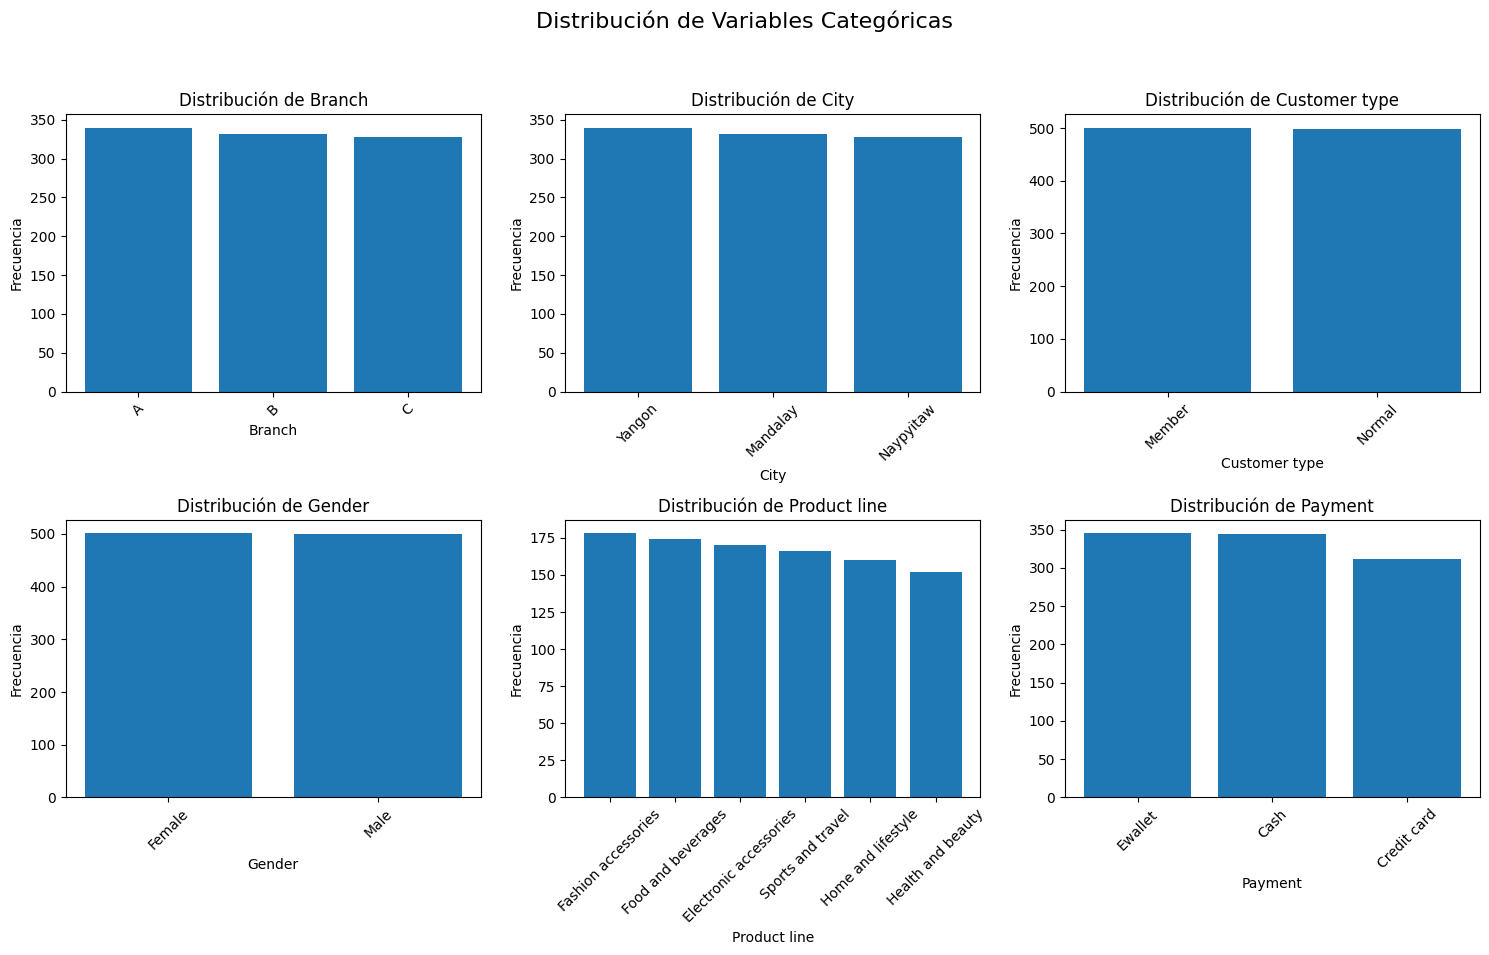

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determinar el número de filas y columnas para los subplots
num_cols = 3  # Número de columnas en la cuadrícula de subplots
num_rows = (len(categorical_cols) + 1) // num_cols  # Calcula el número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle("Distribución de Variables Categóricas", fontsize=16)

# Aplanar el arreglo de ejes para iterar fácilmente
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    value_counts = df[col].value_counts()
    ax.bar(value_counts.index, value_counts.values)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis='x', rotation=45)

# Eliminar cualquier subplot vacío si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# contador de columna Month
df['Month'].value_counts()

,count
Month,
1,352
3,345
2,303


In [ ]:
# Contador de generos
df['Gender'].value_counts()

,count
Gender,
Female,501
Male,499


In [ ]:
# Contador de genero y tipos de pago
df[['Gender','Payment']].value_counts(ascending=True).to_dict()

{('Male', 'Credit card'): 148,
 ('Female', 'Ewallet'): 160,
 ('Female', 'Credit card'): 163,
 ('Male', 'Cash'): 166,
 ('Female', 'Cash'): 178,
 ('Male', 'Ewallet'): 185}

<ipython-input-178-ef0adebf116b>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_payment_counts = df.groupby(['Gender', 'Payment']).size().reset_index(name='Counts')


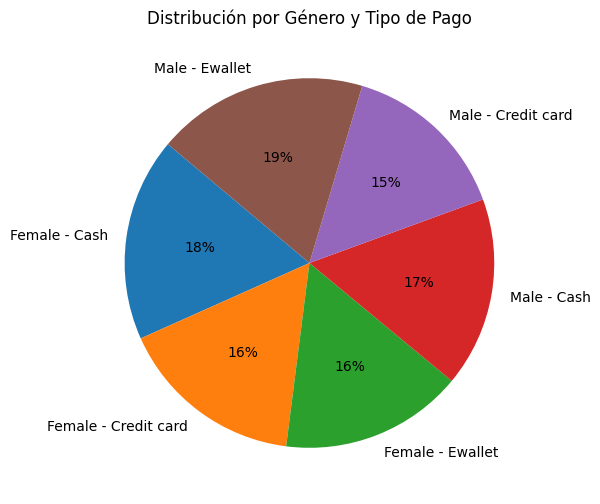

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar combinaciones de Gender y Payment
gender_payment_counts = df.groupby(['Gender', 'Payment']).size().reset_index(name='Counts')

# Preparar datos para el gráfico
labels = [f"{row['Gender']} - {row['Payment']}" for _, row in gender_payment_counts.iterrows()]
sizes = gender_payment_counts['Counts']

# Crear gráfico de pastel
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%.0f%%', startangle=140)
plt.title('Distribución por Género y Tipo de Pago')
plt.show()

In [ ]:
# Descripcion de datos númericos
df.describe()

,Unit price,Quantity,Total,Day,Month,Year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0
mean,55.672130,5.510000,322.966749,15.256000,1.993000,2019.0
std,26.494628,2.923431,245.885335,8.693563,0.835254,0.0
min,10.080000,1.000000,10.678500,1.000000,1.000000,2019.0
25%,32.875000,3.000000,124.422375,8.000000,1.000000,2019.0
50%,55.230000,5.000000,253.848000,15.000000,2.000000,2019.0
75%,77.935000,8.000000,471.350250,23.000000,3.000000,2019.0
max,99.960000,10.000000,1042.650000,31.000000,3.000000,2019.0


            Unit price  Quantity     Total
Unit price    1.000000  0.010778  0.633962
Quantity      0.010778  1.000000  0.705510
Total         0.633962  0.705510  1.000000


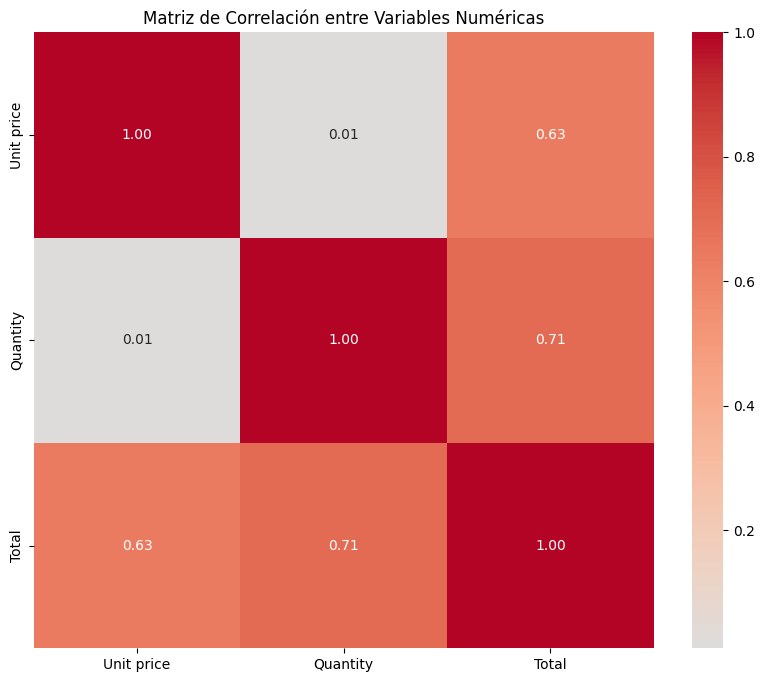

In [ ]:
# Correlación de los datos numéricos
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

# Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

In [ ]:
# Función para identificar outliers usando IQR
def identify_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definición de límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificación de outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices.extend(outliers.index.tolist())

    return set(outlier_indices)

# Identificando outliers en las variables numéricas
outlier_indices = identify_outliers_iqr(df, numerical_cols)
num_outliers = len(outlier_indices)
num_data = len(df)

print(f"Número total de outliers identificados: {num_outliers}")
print(f"Porcentaje de outliers: {(num_outliers / num_data) * 100:.2f}%")

Número total de outliers identificados: 9
Porcentaje de outliers: 0.90%


In [ ]:
# Filtrar el DataFrame sin outliers
df_no_outliers = df.drop(index=outlier_indices)
print(f"Tamaño del DataFrame con outliers: {df.shape}")
print(f"Tamaño del DataFrame sin outliers: {df_no_outliers.shape}")

Tamaño del DataFrame con outliers: (1000, 12)
Tamaño del DataFrame sin outliers: (991, 12)


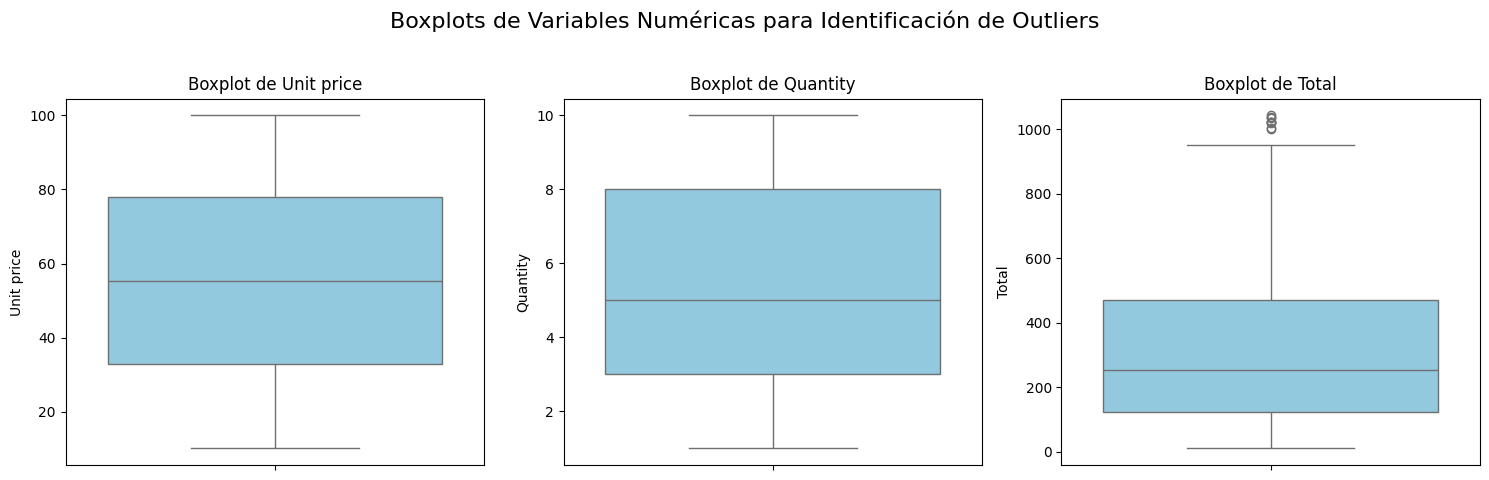

In [ ]:
# Definir el tamaño del gráfico y la cuadrícula de subplots
num_cols = 3  # Número de columnas de subplots
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols  # Número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle("Boxplots de Variables Numéricas para Identificación de Outliers", fontsize=16)

# Aplanar los ejes para iterar más fácilmente
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.boxplot(data=df, y=col, ax=ax, color='skyblue')
    ax.set_title(f"Boxplot de {col}")

# Eliminar subplots vacíos si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajusta el espaciado para el título principal
plt.show()

In [ ]:
# Filtrar el DataFrame sin outliers
df = df.drop(index=outlier_indices)

In [ ]:
# Información de los datos limpios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Branch         1000 non-null   category
 1   City           1000 non-null   category
 2   Customer type  1000 non-null   category
 3   Gender         1000 non-null   category
 4   Product line   1000 non-null   category
 5   Unit price     1000 non-null   float64 
 6   Quantity       1000 non-null   int64   
 7   Total          1000 non-null   float64 
 8   Payment        1000 non-null   category
 9   Day            1000 non-null   int32   
 10  Month          1000 non-null   int32   
 11  Year           1000 non-null   int32   
dtypes: category(6), float64(2), int32(3), int64(1)
memory usage: 42.0 KB


#Parte 1: Preprocesamiento de Datos

**Limpieza de Datos:**
* Tratar los valores nulos utilizando técnicas adecuadas (imputación, eliminación, etc.).
* Manejar los outliers mediante técnicas de filtrado o transformación.

**Transformación de Columnas:**
* Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.
* Realizar codificación de variables categóricas utilizando técnicas como One-Hot Encoding.
* Escalar las variables numéricas usando StandardScaler u otros métodos de normalización.

**Creación de Pipelines:**
* Crear pipelines utilizando Pipeline de sklearn para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.
* Incluir todos los pasos de preprocesamiento en el pipeline.

***- Valores nulos***

In [ ]:
# Verificar valores nulos
df.isna().sum()

,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Total,0
Payment,0
Day,0


***- Valores outlier***

In [ ]:
# Función para identificar outliers usando IQR
def identify_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definición de límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificación de outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices.extend(outliers.index.tolist())

    return set(outlier_indices)

# Identificando outliers en las variables numéricas
outlier_indices = identify_outliers_iqr(df, numerical_cols)
num_outliers = len(outlier_indices)
num_data = len(df)

print(f"Número total de outliers identificados: {num_outliers}")
print(f"Porcentaje de outliers: {(num_outliers / num_data) * 100:.2f}%")

Número total de outliers identificados: 9
Porcentaje de outliers: 0.90%


***- Visualizar columnas***

In [ ]:
# Visualizar columnas categoricas
df[categorical_cols].columns

Index(['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment'], dtype='object')

In [ ]:
# Visualizar columnas numericas
df[numerical_cols].columns

Index(['Unit price', 'Quantity', 'Total'], dtype='object')

In [ ]:
df.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Total,Payment,Day,Month,Year
0,A,Yangon,Member,Female,Health and beauty,74.69,7,548.9715,Ewallet,5,1,2019
1,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,80.2200,Cash,8,3,2019
2,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,340.5255,Credit card,3,3,2019
3,A,Yangon,Member,Male,Health and beauty,58.22,8,489.0480,Ewallet,27,1,2019
4,A,Yangon,Normal,Male,Sports and travel,86.31,7,634.3785,Ewallet,8,2,2019


***- Transformación de Columnas y División del conjunto de datos en entrenamiento y prueba.***

In [ ]:
# Transformación de datos por Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Tipos de variable con la nueva distribución
categorical  = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
numerical = ['Unit price', 'Quantity']

# Crear transformaciones específicas para cada tipo de columna
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Crear el ColumnTransformer para aplicar las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical),
        ('num', numerical_transformer, numerical),
    ]
)

# Crear el pipeline final
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Separar la columna objetivo 'Total'
target = df['Total']

# Excluir la columna 'Total' de las características a transformar
X = df.drop(columns=['Total'])
y = target

# Aplicar el preprocesamiento al DataFrame
df_transform = pipeline.fit_transform(X)

# Convertir el resultado a un DataFrame para una vista clara
df_transform = pd.DataFrame(df_transform, columns=pipeline.named_steps['preprocessor'].get_feature_names_out())

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_transform, y, test_size=0.3, random_state=42)

# Mostrar los primeros registros
df_transform.head()

,cat__Branch_B,cat__Branch_C,cat__City_Naypyitaw,cat__City_Yangon,cat__Customer type_Normal,cat__Gender_Male,cat__Product line_Fashion accessories,cat__Product line_Food and beverages,cat__Product line_Health and beauty,cat__Product line_Home and lifestyle,cat__Product line_Sports and travel,cat__Payment_Credit card,cat__Payment_Ewallet,num__Unit price,num__Quantity
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.718160,0.509930
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.525303,-0.174540
2,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.352781,0.509930
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.096214,0.852165
4,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.156959,0.509930


***- División del conjunto de datos en entrenamiento y prueba.***

# Parte 2: Selección de Técnica de Machine Learning

**Entrenamiento Inicial:**
* Entrenar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost, LGBM).
* Evaluar los modelos utilizando validación cruzada y seleccionar el modelo con el mejor rendimiento inicial.

**Comparación de Modelos:**
* Comparar los modelos utilizando métricas de rendimiento relevantes (exactitud, precisión, recall, F1-Score, ROC-AUC, etc.).
* Seleccionar la técnica de machine learning más adecuada basándose en las métricas y la naturaleza del problema.

***- Modelos de machine learning***

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definición de los modelos de regresión
models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor()
}

# Entrenamiento, predicción y evaluación de cada modelo
results = []

# Entrenar y evaluar cada modelo de regresión
for model_name, model in models.items():
    # Crear y entrenar el modelo
    model.fit(X_train, y_train)

    # Predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Evaluación del modelo
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Almacenar resultados
    results.append({
        'Modelo': model_name,
        'R^2': r2,
        'MAE': mse,
        'RMSE': rmse
    })

    print(f"\nModelo: {model_name}")
    print(f"MSE:, {mse:.2f}")
    print(f"RMSE:, {rmse:.2f}")
    print(f"R²:, {r2:.2f}")


Modelo: Linear Regression
MSE:, 7006.90
RMSE:, 83.71
R²:, 0.89

Modelo: K-Nearest Neighbors
MSE:, 5773.63
RMSE:, 75.98
R²:, 0.91

Modelo: Decision Tree
MSE:, 166.26
RMSE:, 12.89
R²:, 1.00

Modelo: Random Forest
MSE:, 91.91
RMSE:, 9.59
R²:, 1.00


***- Validación cruzada***

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

# Definir modelos de regresión
models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor()
}

# Realizar validación cruzada en cada modelo de regresión
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nModelo: {model_name}")
    print(f"R^2 promedio de validación cruzada: {cv_scores.mean():.4f}")
    print(f"Desviación estándar de R^2: {cv_scores.std():.4f}")
    print(f"R^2 por partición: {cv_scores}")


Modelo: Linear Regression
R^2 promedio de validación cruzada: 0.8803
Desviación estándar de R^2: 0.0062
R^2 por partición: [0.88586929 0.88489246 0.86865179 0.87995405 0.88220772]

Modelo: K-Nearest Neighbors
R^2 promedio de validación cruzada: 0.9019
Desviación estándar de R^2: 0.0102
R^2 por partición: [0.90190471 0.89989147 0.91641796 0.90646001 0.88501858]

Modelo: Random Forest Regressor
R^2 promedio de validación cruzada: 0.9972
Desviación estándar de R^2: 0.0007
R^2 por partición: [0.99786413 0.99681955 0.99761213 0.99770493 0.99613305]

Modelo: Decision Tree Regressor
R^2 promedio de validación cruzada: 0.9930
Desviación estándar de R^2: 0.0009
R^2 por partición: [0.99253714 0.99397617 0.99401106 0.99270254 0.99159336]


# Parte 3: Optimización de Hiperparámetros

**GridSearchCV:**
* Implementar GridSearchCV para realizar una búsqueda exhaustiva de los mejores hiperparámetros para el modelo seleccionado.
* Definir el espacio de búsqueda para los hiperparámetros relevantes.

**RandomizedSearchCV:**
* Implementar RandomizedSearchCV para realizar una búsqueda aleatoria de los mejores hiperparámetros, especialmente útil si el espacio de búsqueda es grande.
Optuna:
* Implementar Optuna para una optimización avanzada de los hiperparámetros, aprovechando técnicas como la optimización bayesiana y el pruning.

**Evaluación de Modelos Optimizados:**
* Entrenar el modelo con los mejores hiperparámetros encontrados y evaluar su rendimiento en el conjunto de prueba.
* Comparar el rendimiento del modelo optimizado con el modelo inicial.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir el espacio de búsqueda de hiperparámetros para Random Forest y Decision Tree
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Crear el objeto GridSearchCV para Random Forest
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, cv=5, scoring='neg_mean_squared_error')
grid_rf.fit(X_train, y_train)

# Ver los mejores hiperparámetros para Random Forest
print(f"Best parameters for Random Forest: {grid_rf.best_params_}")

# Evaluar el modelo con los mejores hiperparámetros
y_pred_rf = grid_rf.best_estimator_.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Optimized - MSE: {mse_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.2f}")


Best parameters for Random Forest: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Optimized - MSE: 85.11, RMSE: 9.23, R²: 1.00


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definir el espacio de búsqueda de hiperparámetros para Random Forest
param_dist_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Crear el objeto RandomizedSearchCV para Random Forest
random_rf = RandomizedSearchCV(estimator=RandomForestRegressor(), param_distributions=param_dist_rf, n_iter=100, cv=5, scoring='neg_mean_squared_error', random_state=42)
random_rf.fit(X_train, y_train)

# Ver los mejores hiperparámetros para Random Forest
print(f"Best parameters for Random Forest from RandomizedSearch: {random_rf.best_params_}")

# Evaluar el modelo con los mejores hiperparámetros
y_pred_rf_rand = random_rf.best_estimator_.predict(X_test)
mse_rf_rand = mean_squared_error(y_test, y_pred_rf_rand)
rmse_rf_rand = np.sqrt(mse_rf_rand)
r2_rf_rand = r2_score(y_test, y_pred_rf_rand)

print(f"Random Forest Optimized - MSE: {mse_rf_rand:.2f}, RMSE: {rmse_rf_rand:.2f}, R²: {r2_rf_rand:.2f}")


Best parameters for Random Forest from RandomizedSearch: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Optimized - MSE: 95.03, RMSE: 9.75, R²: 1.00


# EDA Dataset II

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/iammustafatz/diabetes-prediction-dataset/versions/1


In [ ]:
import pandas as pd
# Ruta de archivo CSV
data = pd.read_csv(path + "/diabetes_prediction_dataset.csv")
# Mostrar registros
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [ ]:
# hacer una copia del dato original
df = data.copy()
# Datos nulos
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
# Contar los valos unicos de df
df.nunique()

,0
gender,3
age,102
hypertension,2
heart_disease,2
smoking_history,6
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2


In [ ]:
# Informacion de DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
# Columnas númericas y categoricas
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
# Convertir columnas categoricas a tipo 'category'
df[categorical_cols] = df[categorical_cols].astype('category')

In [ ]:
# Valores unicos de columnas categoricas
for col in categorical_cols:
    print(f"Valores únicos en la columna '{col}':")
    print(df[col].unique())
    print()

Valores únicos en la columna 'gender':
['Female', 'Male', 'Other']
Categories (3, object): ['Female', 'Male', 'Other']

Valores únicos en la columna 'smoking_history':
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Categories (6, object): ['No Info', 'current', 'ever', 'former', 'never', 'not current']



In [ ]:
# Contar datos duplicardos
df.duplicated().sum()

3854

In [ ]:
# Eliminar datos duplicados
df = df.drop_duplicates()

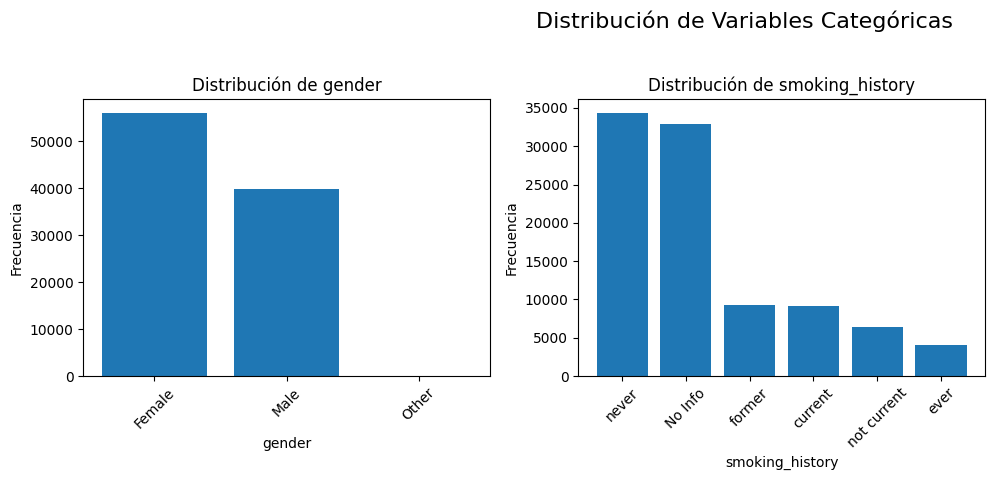

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determinar el número de filas y columnas para los subplots
num_cols = 3  # Número de columnas en la cuadrícula de subplots
num_rows = (len(categorical_cols) + 1) // num_cols  # Calcula el número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle("Distribución de Variables Categóricas", fontsize=16)

# Aplanar el arreglo de ejes para iterar fácilmente
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    value_counts = df[col].value_counts()
    ax.bar(value_counts.index, value_counts.values)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis='x', rotation=45)

# Eliminar cualquier subplot vacío si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Contador de genero e historial de tabaquismo
df[['gender','smoking_history']].value_counts(ascending=True).to_dict()

{('Other', 'ever'): 1,
 ('Other', 'never'): 3,
 ('Other', 'No Info'): 6,
 ('Other', 'not current'): 8,
 ('Male', 'ever'): 1761,
 ('Female', 'ever'): 2236,
 ('Male', 'not current'): 2496,
 ('Female', 'not current'): 3863,
 ('Male', 'current'): 4186,
 ('Male', 'former'): 4556,
 ('Female', 'former'): 4743,
 ('Female', 'current'): 5011,
 ('Male', 'never'): 12056,
 ('Male', 'No Info'): 14912,
 ('Female', 'No Info'): 17969,
 ('Female', 'never'): 22339}

In [ ]:
# Descripcion de datos númericos
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


                          age  hypertension  heart_disease       bmi  \
age                  1.000000      0.257305       0.238451  0.344797   
hypertension         0.257305      1.000000       0.119982  0.148111   
heart_disease        0.238451      0.119982       1.000000  0.061376   
bmi                  0.344797      0.148111       0.061376  1.000000   
HbA1c_level          0.106719      0.081441       0.068140  0.084423   
blood_glucose_level  0.114317      0.084834       0.070832  0.092543   
diabetes             0.264927      0.195710       0.170711  0.214932   

                     HbA1c_level  blood_glucose_level  diabetes  
age                     0.106719             0.114317  0.264927  
hypertension            0.081441             0.084834  0.195710  
heart_disease           0.068140             0.070832  0.170711  
bmi                     0.084423             0.092543  0.214932  
HbA1c_level             1.000000             0.171615  0.406408  
blood_glucose_level     0.1

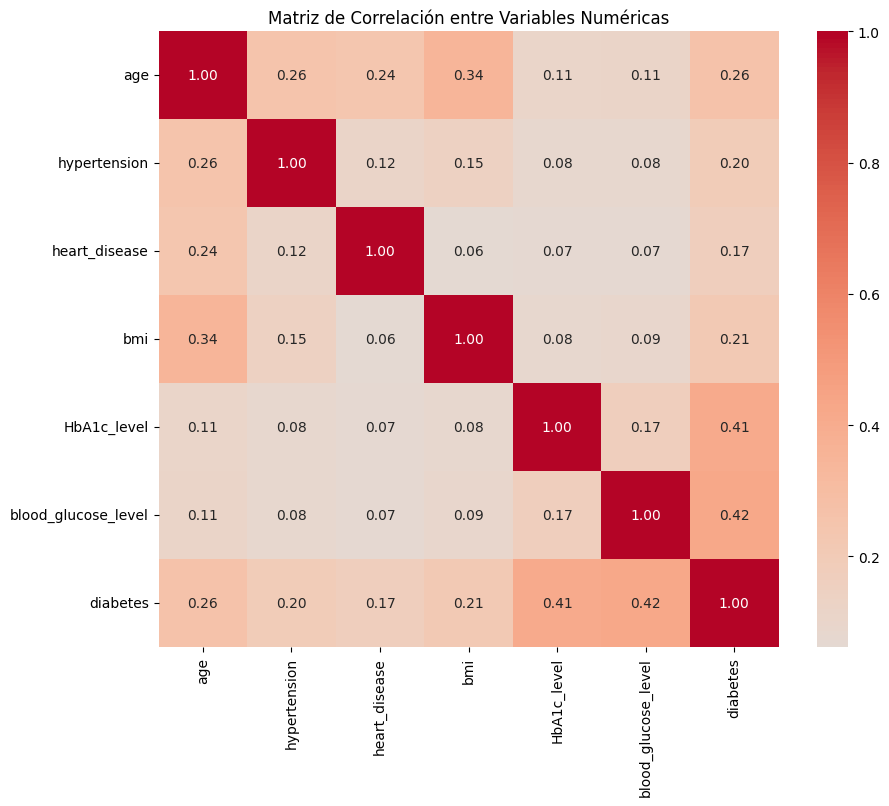

In [ ]:
# Correlación de los datos numéricos
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

# Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

In [ ]:
# Función para identificar outliers usando IQR
def identify_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definición de límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificación de outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices.extend(outliers.index.tolist())

    return set(outlier_indices)

# Identificando outliers en las variables numéricas
outlier_indices = identify_outliers_iqr(df, numerical_cols)
num_outliers = len(outlier_indices)
num_data = len(df)

print(f"Número total de outliers identificados: {num_outliers}")
print(f"Porcentaje de outliers: {(num_outliers / num_data) * 100:.2f}%")

Número total de outliers identificados: 19505
Porcentaje de outliers: 20.29%


In [ ]:
# Filtrar el DataFrame sin outliers
df_no_outliers = df.drop(index=outlier_indices)
print(f"Tamaño del DataFrame con outliers: {df.shape}")
print(f"Tamaño del DataFrame sin outliers: {df_no_outliers.shape}")

Tamaño del DataFrame con outliers: (96146, 9)
Tamaño del DataFrame sin outliers: (76641, 9)


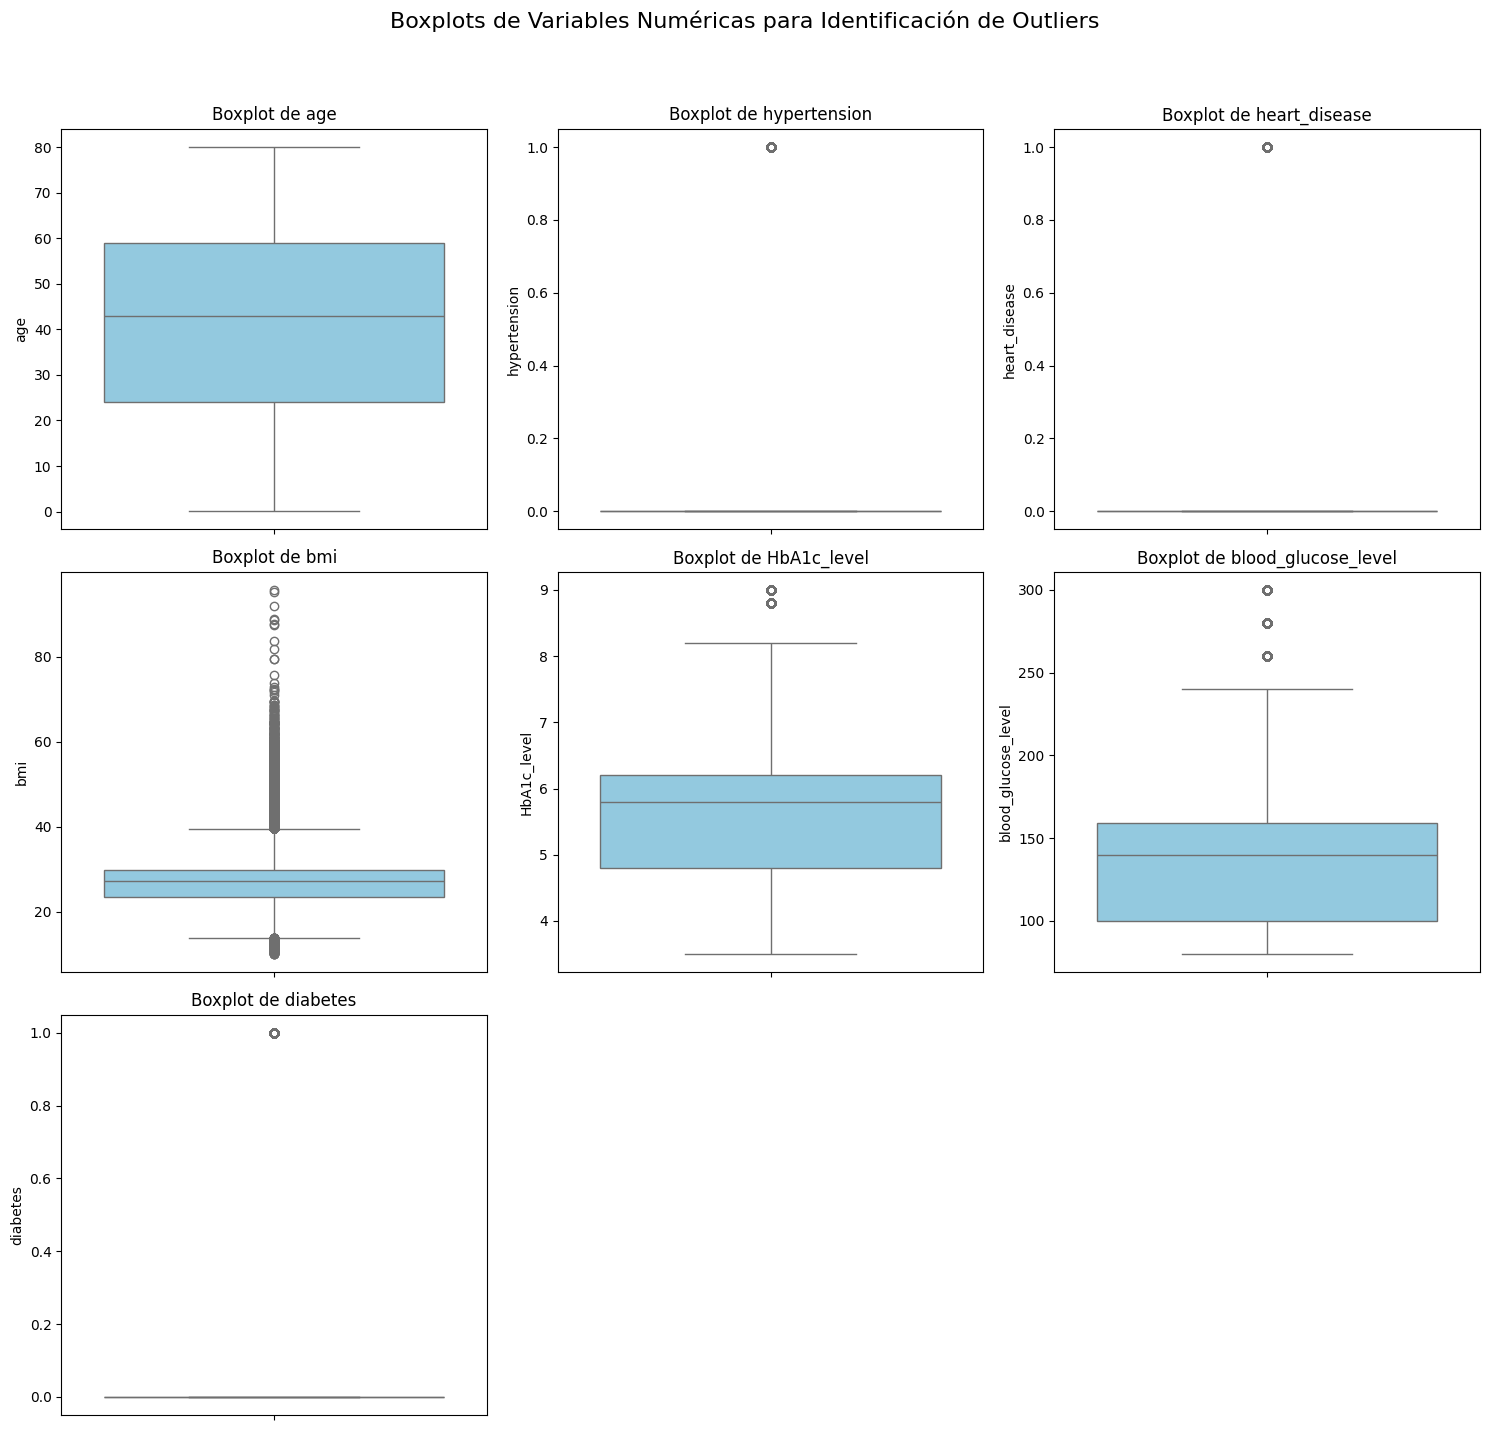

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir el tamaño del gráfico y la cuadrícula de subplots
num_cols = 3  # Número de columnas de subplots
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols  # Número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle("Boxplots de Variables Numéricas para Identificación de Outliers", fontsize=16)

# Aplanar los ejes para iterar más fácilmente
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.boxplot(data=df, y=col, ax=ax, color='skyblue')
    ax.set_title(f"Boxplot de {col}")

# Eliminar subplots vacíos si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Filtrar el DataFrame sin outliers
# df = df.drop(index=outlier_indices)

In [ ]:
# Información de los datos limpios
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   gender               96146 non-null  category
 1   age                  96146 non-null  float64 
 2   hypertension         96146 non-null  int64   
 3   heart_disease        96146 non-null  int64   
 4   smoking_history      96146 non-null  category
 5   bmi                  96146 non-null  float64 
 6   HbA1c_level          96146 non-null  float64 
 7   blood_glucose_level  96146 non-null  int64   
 8   diabetes             96146 non-null  int64   
dtypes: category(2), float64(3), int64(4)
memory usage: 8.1 MB


#Parte 1: Preprocesamiento de Datos

**Limpieza de Datos:**
* Tratar los valores nulos utilizando técnicas adecuadas (imputación, eliminación, etc.).
* Manejar los outliers mediante técnicas de filtrado o transformación.

**Transformación de Columnas:**
* Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.
* Realizar codificación de variables categóricas utilizando técnicas como One-Hot Encoding.
* Escalar las variables numéricas usando StandardScaler u otros métodos de normalización.

**Creación de Pipelines:**
* Crear pipelines utilizando Pipeline de sklearn para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.
* Incluir todos los pasos de preprocesamiento en el pipeline.

***- Valores nulos***

In [ ]:
# Verificar valores nulos
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


***- Valores outlier***

In [ ]:
# Función para identificar outliers usando IQR
def identify_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definición de límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificación de outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices.extend(outliers.index.tolist())

    return set(outlier_indices)

# Identificando outliers en las variables numéricas
outlier_indices = identify_outliers_iqr(df, numerical_cols)
num_outliers = len(outlier_indices)
num_data = len(df)

print(f"Número total de outliers identificados: {num_outliers}")
print(f"Porcentaje de outliers: {(num_outliers / num_data) * 100:.2f}%")

Número total de outliers identificados: 19505
Porcentaje de outliers: 20.29%


***- Visualizar columnas***

In [ ]:
# Visualizar columnas categoricas
df[categorical_cols].columns.tolist()

['gender', 'smoking_history']

In [ ]:
# Visualizar columnas numericas
df[numerical_cols].columns.tolist()

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


***- Transformación de Columnas y División del conjunto de datos en entrenamiento y prueba.***

In [ ]:
# Transformación de datos por Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Tipos de variable con la nueva distribución
categorical  = ['gender', 'smoking_history']
numerical = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

# Crear transformaciones específicas para cada tipo de columna
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Crear el ColumnTransformer para aplicar las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical),
        ('num', numerical_transformer, numerical),
    ]
)

# Crear el pipeline final
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Excluir la columna 'Total' de las características a transformar
X = df.drop(columns=['diabetes'])
y = df['diabetes']

# Aplicar el preprocesamiento al DataFrame
df_transform = pipeline.fit_transform(X)

# Convertir el resultado a un DataFrame para una vista clara
df_transform = pd.DataFrame(df_transform, columns=pipeline.named_steps['preprocessor'].get_feature_names_out())

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_transform, y, test_size=0.3, random_state=42)

# Mostrar los primeros registros
df_transform.head()

,cat__gender_Male,cat__gender_Other,cat__smoking_history_current,cat__smoking_history_ever,cat__smoking_history_former,cat__smoking_history_never,cat__smoking_history_not current,num__age,num__hypertension,num__heart_disease,num__bmi,num__HbA1c_level,num__blood_glucose_level
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.700840,-0.290050,4.848534,-0.314947,0.994563,0.043554
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.543372,-0.290050,-0.206248,-0.000216,0.994563,-1.423096
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.614096,-0.290050,-0.206248,-0.000216,0.155970,0.483549
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.257952,-0.290050,-0.206248,-0.572051,-0.496269,0.410216
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.522768,3.447677,4.848534,-1.061141,-0.682623,0.410216


***- División del conjunto de datos en entrenamiento y prueba.***

# Parte 2: Selección de Técnica de Machine Learning

**Entrenamiento Inicial:**
* Entrenar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost, LGBM).
* Evaluar los modelos utilizando validación cruzada y seleccionar el modelo con el mejor rendimiento inicial.

**Comparación de Modelos:**
* Comparar los modelos utilizando métricas de rendimiento relevantes (exactitud, precisión, recall, F1-Score, ROC-AUC, etc.).
* Seleccionar la técnica de machine learning más adecuada basándose en las métricas y la naturaleza del problema.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Definición de los modelos de clasificación
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Resultados almacenados
results = []

# Entrenar y evaluar cada modelo de clasificación
for model_name, model in models.items():
    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Métricas de evaluación
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)  # Guardar el reporte como diccionario

    # Almacenar resultados
    results.append({
        'Modelo': model_name,
        'Accuracy': accuracy,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    })

    # Imprimir resultados por modelo
    print(f"\n=== Modelo: {model_name} ===")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {report['weighted avg']['precision']:.2f}")
    print(f"Recall: {report['weighted avg']['recall']:.2f}")
    print(f"F1-Score: {report['weighted avg']['f1-score']:.2f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# Mostrar resumen final de resultados
import pandas as pd
results_df = pd.DataFrame(results)
print("\n=== Resumen de Resultados ===")
print(results_df)



=== Modelo: Logistic Regression ===
Accuracy: 0.96
Precision: 0.96
Recall: 0.96
F1-Score: 0.96
Confusion Matrix:
[[26008   259]
 [  941  1636]]

=== Modelo: K-Nearest Neighbors ===
Accuracy: 0.96
Precision: 0.96
Recall: 0.96
F1-Score: 0.96
Confusion Matrix:
[[26048   219]
 [  982  1595]]

=== Modelo: Decision Tree ===
Accuracy: 0.95
Precision: 0.95
Recall: 0.95
F1-Score: 0.95
Confusion Matrix:
[[25492   775]
 [  659  1918]]

=== Modelo: Random Forest ===
Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1-Score: 0.97
Confusion Matrix:
[[26161   106]
 [  797  1780]]

=== Resumen de Resultados ===
                Modelo  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.958397   0.955991  0.958397  0.955491
1  K-Nearest Neighbors  0.958362   0.956130  0.958362  0.955043
2        Decision Tree  0.950284   0.951340  0.950284  0.950776
3        Random Forest  0.968694   0.968055  0.968694  0.966473


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score

# Definir modelos de clasificación
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Realizar validación cruzada en cada modelo de clasificación
for model_name, model in models.items():
    # Usar F1-score como métrica de validación cruzada
    scorer = make_scorer(f1_score, average='weighted')
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring=scorer)

    print(f"\nModelo: {model_name}")
    print(f"F1-score promedio de validación cruzada: {cv_scores.mean():.4f}")
    print(f"Desviación estándar de F1-score: {cv_scores.std():.4f}")
    print(f"F1-score por partición: {cv_scores}")



Modelo: Logistic Regression
F1-score promedio de validación cruzada: 0.9562
Desviación estándar de F1-score: 0.0009
F1-score por partición: [0.95488944 0.95606054 0.95631132 0.95603424 0.95766718]

Modelo: K-Nearest Neighbors
F1-score promedio de validación cruzada: 0.9551
Desviación estándar de F1-score: 0.0012
F1-score por partición: [0.95280681 0.95486653 0.9559427  0.95585298 0.95608538]

Modelo: Decision Tree
F1-score promedio de validación cruzada: 0.9495
Desviación estándar de F1-score: 0.0020
F1-score por partición: [0.94858932 0.95215299 0.94614518 0.95035684 0.95047636]

Modelo: Random Forest
F1-score promedio de validación cruzada: 0.9668
Desviación estándar de F1-score: 0.0009
F1-score por partición: [0.96539358 0.9682191  0.96636923 0.9669654  0.96720538]


# Parte 3: Optimización de Hiperparámetros

**GridSearchCV:**
* Implementar GridSearchCV para realizar una búsqueda exhaustiva de los mejores hiperparámetros para el modelo seleccionado.
* Definir el espacio de búsqueda para los hiperparámetros relevantes.

**RandomizedSearchCV:**
* Implementar RandomizedSearchCV para realizar una búsqueda aleatoria de los mejores hiperparámetros, especialmente útil si el espacio de búsqueda es grande.
Optuna:
* Implementar Optuna para una optimización avanzada de los hiperparámetros, aprovechando técnicas como la optimización bayesiana y el pruning.

**Evaluación de Modelos Optimizados:**
* Entrenar el modelo con los mejores hiperparámetros encontrados y evaluar su rendimiento en el conjunto de prueba.
* Comparar el rendimiento del modelo optimizado con el modelo inicial.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Pipeline para Regresión Logística
pipeline_lr = Pipeline([
    ('logisticregression', LogisticRegression(max_iter=1000, random_state=42))
])

# Espacio de hiperparámetros
param_grid_lr = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],  # Valores del parámetro de regularización
    'logisticregression__solver': ['liblinear', 'saga']  # Solvers compatibles
}

# Configurar GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=5,  # Número de folds para validación cruzada
    scoring='accuracy',  # Métrica a optimizar
    verbose=2,  # Mostrar progreso
    n_jobs=-1  # Usar todos los núcleos disponibles
)

# Entrenar GridSearchCV
grid_search_lr.fit(X_train, y_train)

# Resultados del mejor modelo
print("=== Resultados de Regresión Logística ===")
print(f"Mejores Hiperparámetros: {grid_search_lr.best_params_}")
print(f"Mejor Score (accuracy): {grid_search_lr.best_score_:.4f}")

# Evaluar en el conjunto de prueba
best_model_lr = grid_search_lr.best_estimator_
test_accuracy = best_model_lr.score(X_test, y_test)
print(f"Accuracy en conjunto de prueba: {test_accuracy:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
=== Resultados de Regresión Logística ===
Mejores Hiperparámetros: {'logisticregression__C': 100, 'logisticregression__solver': 'liblinear'}
Mejor Score (accuracy): 0.9593
Accuracy en conjunto de prueba: 0.9585


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

# Pipeline para Regresión Logística
pipeline_lr = Pipeline([
    ('logisticregression', LogisticRegression(max_iter=1000, random_state=42))
])

# Espacio de hiperparámetros (usando distribuciones)
param_distributions_lr = {
    'logisticregression__C': uniform(0.01, 10),  # Distribución uniforme entre 0.01 y 10
    'logisticregression__solver': ['liblinear', 'saga']  # Opciones fijas
}

# Configurar RandomizedSearchCV
random_search_lr = RandomizedSearchCV(
    estimator=pipeline_lr,
    param_distributions=param_distributions_lr,
    n_iter=20,  # Número de combinaciones aleatorias a probar
    cv=5,  # Validación cruzada
    scoring='accuracy',  # Métrica a optimizar
    verbose=2,  # Mostrar progreso
    random_state=42,  # Asegurar reproducibilidad
    n_jobs=-1  # Usar todos los núcleos disponibles
)

# Entrenar RandomizedSearchCV
random_search_lr.fit(X_train, y_train)

# Resultados del mejor modelo
print("=== Resultados de Regresión Logística ===")
print(f"Mejores Hiperparámetros: {random_search_lr.best_params_}")
print(f"Mejor Score (accuracy): {random_search_lr.best_score_:.4f}")

# Evaluar en el conjunto de prueba
best_model_lr = random_search_lr.best_estimator_
test_accuracy = best_model_lr.score(X_test, y_test)
print(f"Accuracy en conjunto de prueba: {test_accuracy:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
=== Resultados de Regresión Logística ===
Mejores Hiperparámetros: {'logisticregression__C': 8.334426408004218, 'logisticregression__solver': 'saga'}
Mejor Score (accuracy): 0.9593
Accuracy en conjunto de prueba: 0.9585


***Debido a la demora de la ejecución de Hiperparámetros opte solo por utilizar uno ya que todos los modelos presentan un buen resultado***

# EDA Dataset III

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1


In [ ]:
import pandas as pd
# Ruta de archivo CSV
data = pd.read_csv(path + "/insurance.csv")
# Mostrar registros
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
# hacer una copia del dato original
df = data.copy()
# Datos nulos
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# Contar los valos unicos de df
df.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


In [ ]:
# Mostrar DF
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Informacion de DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Columnas númericas y categoricas
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
# Convertir columnas categoricas a tipo 'category'
df[categorical_cols] = df[categorical_cols].astype('category')

In [ ]:
# Contar datos duplicardos
df.duplicated().sum()

1

In [ ]:
# Eliminar datos duplicados.
df = df.drop_duplicates()

In [ ]:
# Valores unicos de columnas categoricas
for col in categorical_cols:
    print(f"Valores únicos en la columna '{col}':")
    print(df[col].unique())
    print()

Valores únicos en la columna 'sex':
['female', 'male']
Categories (2, object): ['female', 'male']

Valores únicos en la columna 'smoker':
['yes', 'no']
Categories (2, object): ['no', 'yes']

Valores únicos en la columna 'region':
['southwest', 'southeast', 'northwest', 'northeast']
Categories (4, object): ['northeast', 'northwest', 'southeast', 'southwest']



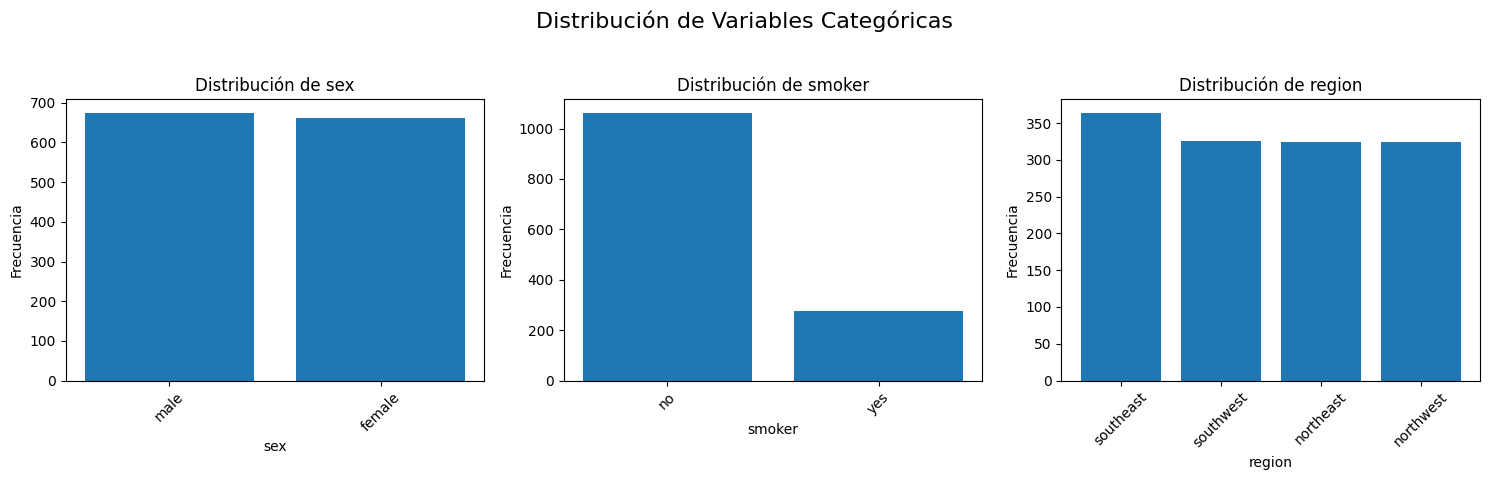

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Valores unicos de columnas categoricas
# Determinar el número de filas y columnas para los subplots
num_cols = 3  # Número de columnas en la cuadrícula de subplots
num_rows = (len(categorical_cols) + 1) // num_cols  # Calcula el número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle("Distribución de Variables Categóricas", fontsize=16)

# Aplanar el arreglo de ejes para iterar fácilmente
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    value_counts = df[col].value_counts()
    ax.bar(value_counts.index, value_counts.values)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis='x', rotation=45)

# Eliminar cualquier subplot vacío si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Contador de generos
df['sex'].value_counts()

,count
sex,
male,675
female,662


In [ ]:
# Contador de genero y tipos de pago
df[['sex','region']].value_counts(ascending=True).to_dict()

{('male', 'northwest'): 160,
 ('female', 'northeast'): 161,
 ('female', 'southwest'): 162,
 ('male', 'northeast'): 163,
 ('male', 'southwest'): 163,
 ('female', 'northwest'): 164,
 ('female', 'southeast'): 175,
 ('male', 'southeast'): 189}

<ipython-input-209-2bfdcbac39cb>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sex_region_counts = df.groupby(['sex', 'region']).size().reset_index(name='Counts')


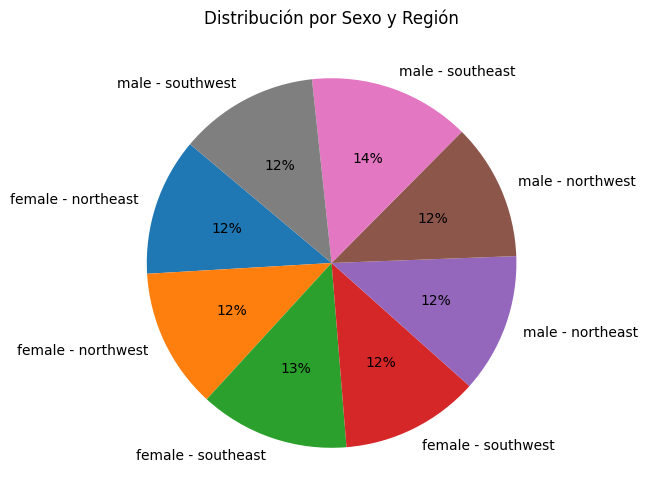

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar combinaciones de sexo y region
sex_region_counts = df.groupby(['sex', 'region']).size().reset_index(name='Counts')

# Preparar datos para el gráfico
labels = [f"{row['sex']} - {row['region']}" for _, row in sex_region_counts.iterrows()]
sizes = sex_region_counts['Counts']

# Crear gráfico de pastel
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%.0f%%', startangle=140)
plt.title('Distribución por Sexo y Región')
plt.show()

In [ ]:
# Descripcion de datos númericos
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


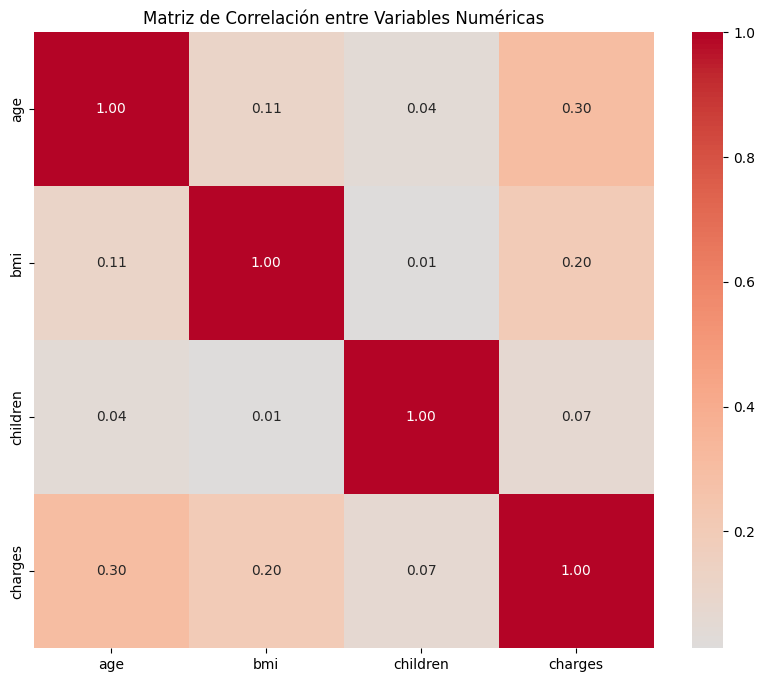

In [ ]:
# Correlación de los datos numéricos
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

# Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

In [ ]:
# Función para identificar outliers usando IQR
def identify_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definición de límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificación de outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices.extend(outliers.index.tolist())

    return set(outlier_indices)

# Identificando outliers en las variables numéricas
outlier_indices = identify_outliers_iqr(df, numerical_cols)
num_outliers = len(outlier_indices)
num_data = len(df)

print(f"Número total de outliers identificados: {num_outliers}")
print(f"Porcentaje de outliers: {(num_outliers / num_data) * 100:.2f}%")

Número total de outliers identificados: 145
Porcentaje de outliers: 10.85%


In [ ]:
# Filtrar el DataFrame sin outliers
df_no_outliers = df.drop(index=outlier_indices)
print(f"Tamaño del DataFrame con outliers: {df.shape}")
print(f"Tamaño del DataFrame sin outliers: {df_no_outliers.shape}")

Tamaño del DataFrame con outliers: (1337, 7)
Tamaño del DataFrame sin outliers: (1192, 7)


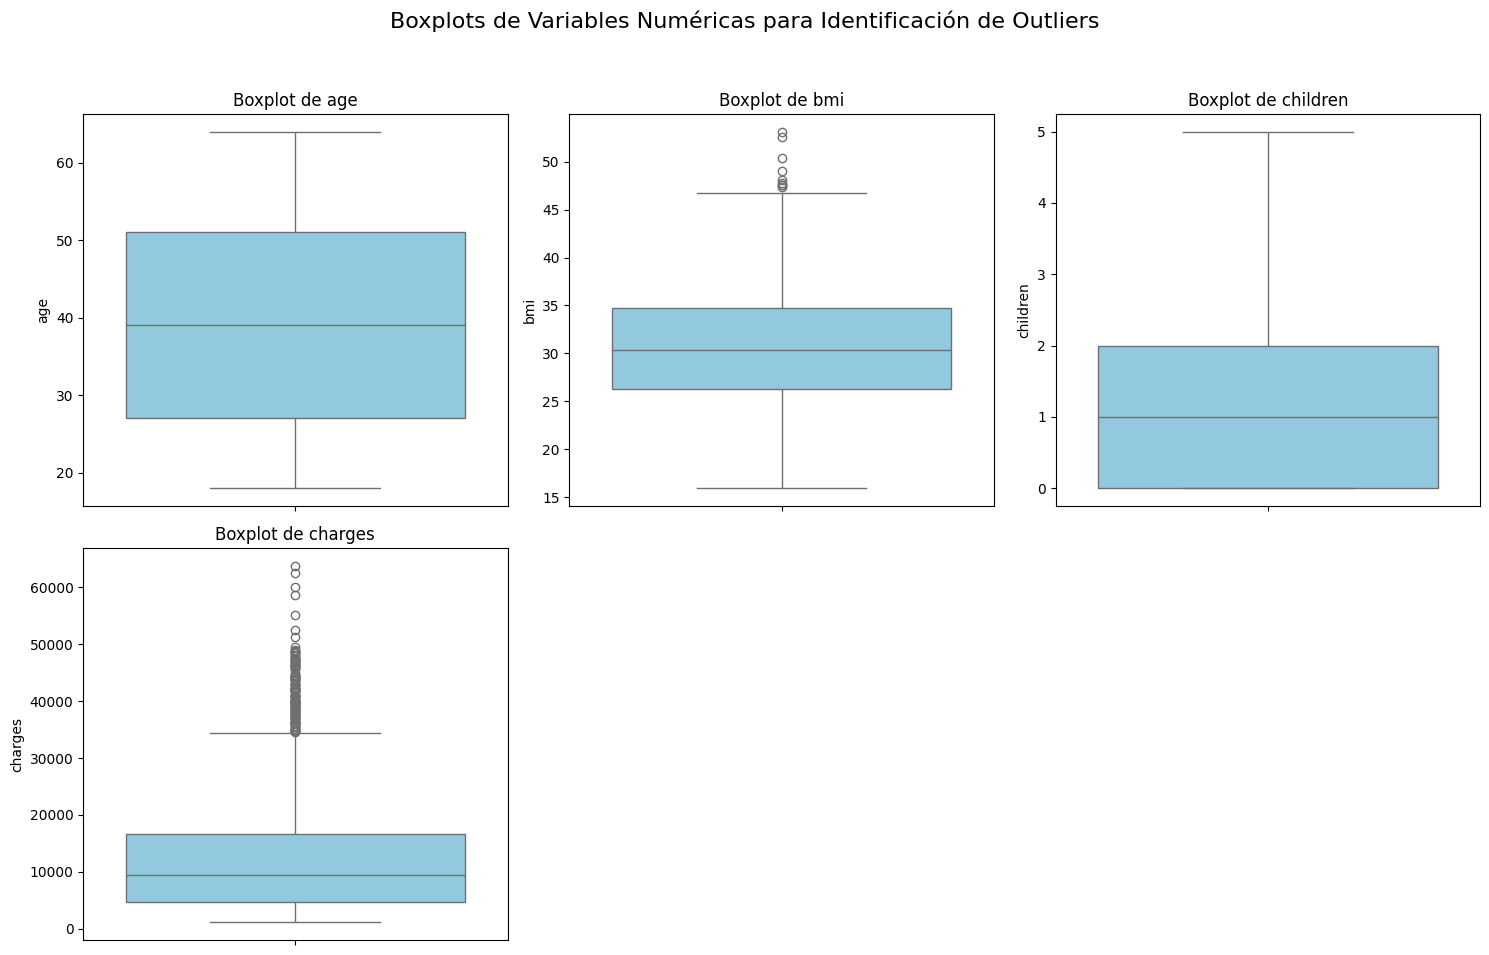

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir el tamaño del gráfico y la cuadrícula de subplots
num_cols = 3  # Número de columnas de subplots
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols  # Número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle("Boxplots de Variables Numéricas para Identificación de Outliers", fontsize=16)

# Aplanar los ejes para iterar más fácilmente
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.boxplot(data=df, y=col, ax=ax, color='skyblue')
    ax.set_title(f"Boxplot de {col}")

# Eliminar subplots vacíos si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajusta el espaciado para el título principal
plt.show()

In [ ]:
# Filtrar el DataFrame sin outliers
df = df.drop(index=outlier_indices)

In [ ]:
# Información de los datos limpios
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1192 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1192 non-null   int64   
 1   sex       1192 non-null   category
 2   bmi       1192 non-null   float64 
 3   children  1192 non-null   int64   
 4   smoker    1192 non-null   category
 5   region    1192 non-null   category
 6   charges   1192 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 50.5 KB


#Parte 1: Preprocesamiento de Datos

**Limpieza de Datos:**
* Tratar los valores nulos utilizando técnicas adecuadas (imputación, eliminación, etc.).
* Manejar los outliers mediante técnicas de filtrado o transformación.

**Transformación de Columnas:**
* Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.
* Realizar codificación de variables categóricas utilizando técnicas como One-Hot Encoding.
* Escalar las variables numéricas usando StandardScaler u otros métodos de normalización.

**Creación de Pipelines:**
* Crear pipelines utilizando Pipeline de sklearn para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.
* Incluir todos los pasos de preprocesamiento en el pipeline.

***- Valores nulos***

In [ ]:
# Verificar valores nulos
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


***- Valores outlier***

In [ ]:
# Función para identificar outliers usando IQR
def identify_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definición de límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificación de outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices.extend(outliers.index.tolist())

    return set(outlier_indices)

# Identificando outliers en las variables numéricas
outlier_indices = identify_outliers_iqr(df, numerical_cols)
num_outliers = len(outlier_indices)
num_data = len(df)

print(f"Número total de outliers identificados: {num_outliers}")
print(f"Porcentaje de outliers: {(num_outliers / num_data) * 100:.2f}%")

Número total de outliers identificados: 62
Porcentaje de outliers: 5.20%


***- Visualizar columnas***

In [ ]:
# Visualizar columnas categoricas
df[categorical_cols].columns.tolist()

['sex', 'smoker', 'region']

In [ ]:
# Visualizar columnas numericas
df[numerical_cols].columns.tolist()

['age', 'bmi', 'children', 'charges']

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


***- Transformación de Columnas y División del conjunto de datos en entrenamiento y prueba.***

In [ ]:
# Transformación de datos por Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Tipos de variable con la nueva distribución
categorical  = ['sex', 'smoker', 'region']
numerical = ['age', 'bmi', 'children']

# Crear transformaciones específicas para cada tipo de columna
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Crear el ColumnTransformer para aplicar las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical),
        ('num', numerical_transformer, numerical),
    ]
)

# Crear el pipeline final
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Separar la columna objetivo 'Total'
target = df['charges']

# Excluir la columna 'Total' de las características a transformar
X = df.drop(columns=['charges'])
y = target

# Aplicar el preprocesamiento al DataFrame
df_transform = pipeline.fit_transform(X)

# Convertir el resultado a un DataFrame para una vista clara
df_transform = pd.DataFrame(df_transform, columns=pipeline.named_steps['preprocessor'].get_feature_names_out())

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_transform, y, test_size=0.3, random_state=42)

# Mostrar los primeros registros
df_transform.head()

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,num__age,num__bmi,num__children
0,0.0,1.0,0.0,0.0,1.0,-1.423210,-0.357608,-0.893545
1,1.0,0.0,0.0,1.0,0.0,-1.494377,0.642929,-0.071070
2,1.0,0.0,0.0,1.0,0.0,-0.782712,0.511683,1.573881
3,1.0,0.0,1.0,0.0,0.0,-0.426879,-1.243092,-0.893545
4,1.0,0.0,1.0,0.0,0.0,-0.498046,-0.190568,-0.893545


***- División del conjunto de datos en entrenamiento y prueba.***

# Parte 2: Selección de Técnica de Machine Learning

**Entrenamiento Inicial:**
* Entrenar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost, LGBM).
* Evaluar los modelos utilizando validación cruzada y seleccionar el modelo con el mejor rendimiento inicial.

**Comparación de Modelos:**
* Comparar los modelos utilizando métricas de rendimiento relevantes (exactitud, precisión, recall, F1-Score, ROC-AUC, etc.).
* Seleccionar la técnica de machine learning más adecuada basándose en las métricas y la naturaleza del problema.

***- Modelos de machine learning***

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definición de los modelos de regresión
models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor()
}

# Entrenamiento, predicción y evaluación de cada modelo
results = []

# Entrenar y evaluar cada modelo de regresión
for model_name, model in models.items():
    # Crear y entrenar el modelo
    model.fit(X_train, y_train)

    # Predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Evaluación del modelo
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Almacenar resultados
    results.append({
        'Modelo': model_name,
        'R^2': r2,
        'MAE': mse,
        'RMSE': rmse
    })

    print(f"\nModelo: {model_name}")
    print(f"MSE:, {mse:.2f}")
    print(f"RMSE:, {rmse:.2f}")
    print(f"R²:, {r2:.2f}")


Modelo: Linear Regression
MSE:, 22115907.06
RMSE:, 4702.76
R²:, 0.61

Modelo: K-Nearest Neighbors
MSE:, 28919404.25
RMSE:, 5377.68
R²:, 0.49

Modelo: Decision Tree
MSE:, 44371785.67
RMSE:, 6661.22
R²:, 0.22

Modelo: Random Forest
MSE:, 23063983.79
RMSE:, 4802.50
R²:, 0.59


***- Validación cruzada***

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

# Definir modelos de regresión
models = {
    'Linear Regression': LinearRegression(),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Random Forest Regressor': RandomForestRegressor(),
    'Decision Tree Regressor': DecisionTreeRegressor()
}

# Realizar validación cruzada en cada modelo de regresión
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nModelo: {model_name}")
    print(f"R^2 promedio de validación cruzada: {cv_scores.mean():.4f}")
    print(f"Desviación estándar de R^2: {cv_scores.std():.4f}")
    print(f"R^2 por partición: {cv_scores}")


Modelo: Linear Regression
R^2 promedio de validación cruzada: 0.5781
Desviación estándar de R^2: 0.1018
R^2 por partición: [0.65312796 0.51311853 0.70190996 0.6051476  0.41730346]

Modelo: K-Nearest Neighbors
R^2 promedio de validación cruzada: 0.4132
Desviación estándar de R^2: 0.0682
R^2 por partición: [0.49074698 0.31129661 0.46751002 0.44009102 0.35648774]

Modelo: Random Forest Regressor
R^2 promedio de validación cruzada: 0.5383
Desviación estándar de R^2: 0.1069
R^2 por partición: [0.63885342 0.45232948 0.62929189 0.59911227 0.37199735]

Modelo: Decision Tree Regressor
R^2 promedio de validación cruzada: 0.1675
Desviación estándar de R^2: 0.1122
R^2 por partición: [0.28047907 0.25230461 0.24265918 0.02834828 0.03360309]


# Parte 3: Optimización de Hiperparámetros

**GridSearchCV:**
* Implementar GridSearchCV para realizar una búsqueda exhaustiva de los mejores hiperparámetros para el modelo seleccionado.
* Definir el espacio de búsqueda para los hiperparámetros relevantes.

**RandomizedSearchCV:**
* Implementar RandomizedSearchCV para realizar una búsqueda aleatoria de los mejores hiperparámetros, especialmente útil si el espacio de búsqueda es grande.
Optuna:
* Implementar Optuna para una optimización avanzada de los hiperparámetros, aprovechando técnicas como la optimización bayesiana y el pruning.

**Evaluación de Modelos Optimizados:**
* Entrenar el modelo con los mejores hiperparámetros encontrados y evaluar su rendimiento en el conjunto de prueba.
* Comparar el rendimiento del modelo optimizado con el modelo inicial.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir los parámetros para GridSearchCV de cada modelo
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Crear el objeto GridSearchCV para Random Forest
grid_rf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid_rf, cv=5, scoring='neg_mean_squared_error')
grid_rf.fit(X_train, y_train)

# Evaluar el modelo con los mejores parámetros
y_pred_rf = grid_rf.best_estimator_.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Optimized - MSE: {mse_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.2f}")



Random Forest Optimized - MSE: 21094285.84, RMSE: 4592.85, R²: 0.63


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definir el espacio de búsqueda para Random Forest
param_dist_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Crear el objeto RandomizedSearchCV para Random Forest
random_rf = RandomizedSearchCV(estimator=RandomForestRegressor(), param_distributions=param_dist_rf, n_iter=100, cv=5, scoring='neg_mean_squared_error', random_state=42)
random_rf.fit(X_train, y_train)

# Evaluar el modelo con los mejores parámetros encontrados
y_pred_rf_rand = random_rf.best_estimator_.predict(X_test)
mse_rf_rand = mean_squared_error(y_test, y_pred_rf_rand)
rmse_rf_rand = np.sqrt(mse_rf_rand)
r2_rf_rand = r2_score(y_test, y_pred_rf_rand)

print(f"Random Forest Optimized from RandomizedSearch - MSE: {mse_rf_rand:.2f}, RMSE: {rmse_rf_rand:.2f}, R²: {r2_rf_rand:.2f}")


Random Forest Optimized from RandomizedSearch - MSE: 21269102.43, RMSE: 4611.84, R²: 0.63


# EDA Dataset IV

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/spscientist/students-performance-in-exams/versions/1


In [ ]:
import pandas as pd
# Ruta de archivo CSV
data = pd.read_csv(path + "/StudentsPerformance.csv")
# Mostrar registros
data

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [ ]:
# hacer una copia del dato original
df = data.copy()
# Datos nulos
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
# Contar los valos unicos de df
df.nunique()

,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


In [ ]:
# Informacion de DF
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
# Columnas númericas y categoricas
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
# Convertir columnas categoricas a tipo 'category'
df[categorical_cols] = df[categorical_cols].astype('category')

In [ ]:
# Contar datos duplicardos
df.duplicated().sum()

0

In [ ]:
# Valores unicos de columnas categoricas
for col in categorical_cols:
    print(f"Valores únicos en la columna '{col}':")
    print(df[col].unique())
    print()

Valores únicos en la columna 'gender':
['female', 'male']
Categories (2, object): ['female', 'male']

Valores únicos en la columna 'race/ethnicity':
['group B', 'group C', 'group A', 'group D', 'group E']
Categories (5, object): ['group A', 'group B', 'group C', 'group D', 'group E']

Valores únicos en la columna 'parental level of education':
['bachelor's degree', 'some college', 'master's degree', 'associate's degree', 'high school', 'some high school']
Categories (6, object): ['associate's degree', 'bachelor's degree', 'high school', 'master's degree',
                         'some college', 'some high school']

Valores únicos en la columna 'lunch':
['standard', 'free/reduced']
Categories (2, object): ['free/reduced', 'standard']

Valores únicos en la columna 'test preparation course':
['none', 'completed']
Categories (2, object): ['completed', 'none']



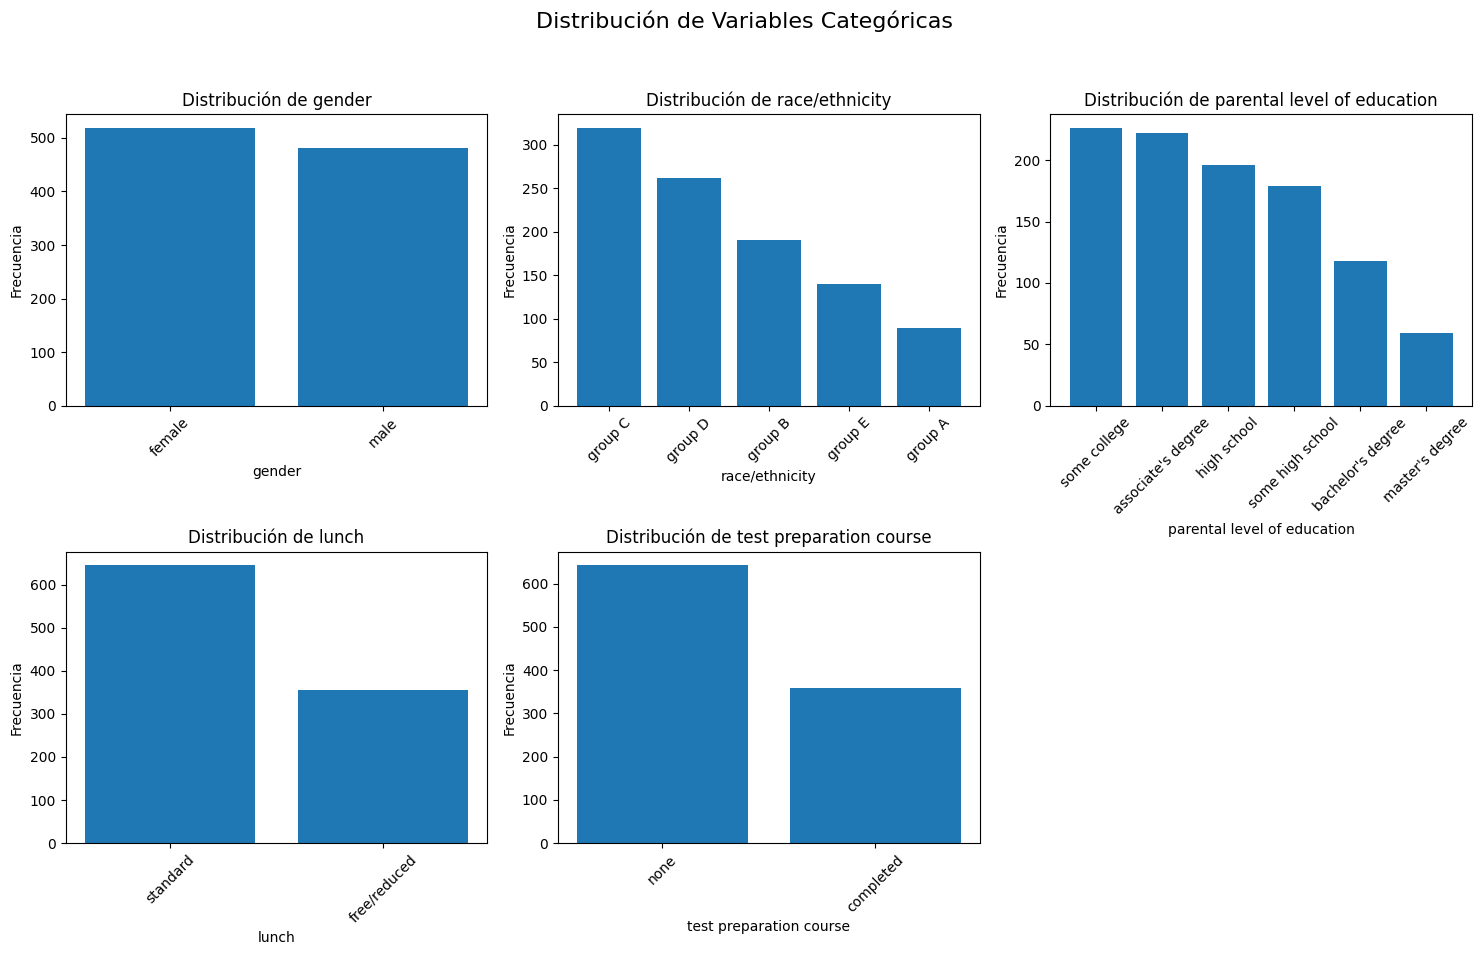

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determinar el número de filas y columnas para los subplots
num_cols = 3  # Número de columnas en la cuadrícula de subplots
num_rows = (len(categorical_cols) + 1) // num_cols  # Calcula el número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle("Distribución de Variables Categóricas", fontsize=16)

# Aplanar el arreglo de ejes para iterar fácilmente
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    value_counts = df[col].value_counts()
    ax.bar(value_counts.index, value_counts.values)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis='x', rotation=45)

# Eliminar cualquier subplot vacío si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Contador de genero y tipos de pago
df[['gender','parental level of education']].value_counts(ascending=True).to_dict()

{('male', "master's degree"): 23,
 ('female', "master's degree"): 36,
 ('male', "bachelor's degree"): 55,
 ('female', "bachelor's degree"): 63,
 ('male', 'some high school'): 88,
 ('female', 'some high school'): 91,
 ('female', 'high school'): 94,
 ('male', 'high school'): 102,
 ('male', "associate's degree"): 106,
 ('male', 'some college'): 108,
 ('female', "associate's degree"): 116,
 ('female', 'some college'): 118}

<ipython-input-239-c9c6dd2779d0>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_education_counts = df.groupby(['gender', 'parental level of education']).size().reset_index(name='Counts')


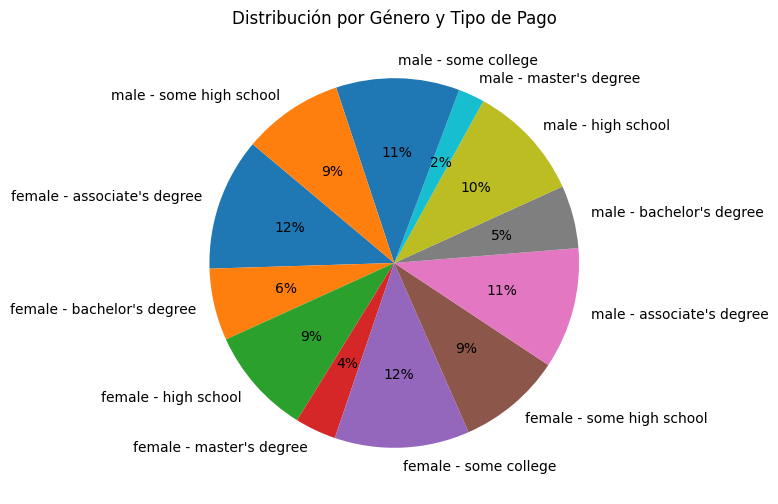

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar combinaciones de Gender y Payment
gender_education_counts = df.groupby(['gender', 'parental level of education']).size().reset_index(name='Counts')

# Preparar datos para el gráfico
labels = [f"{row['gender']} - {row['parental level of education']}" for _, row in gender_education_counts.iterrows()]
sizes = gender_education_counts['Counts']

# Crear gráfico de pastel
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%.0f%%', startangle=140)
plt.title('Distribución por Género y Tipo de Pago')
plt.show()

In [ ]:
# Descripcion de datos númericos
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


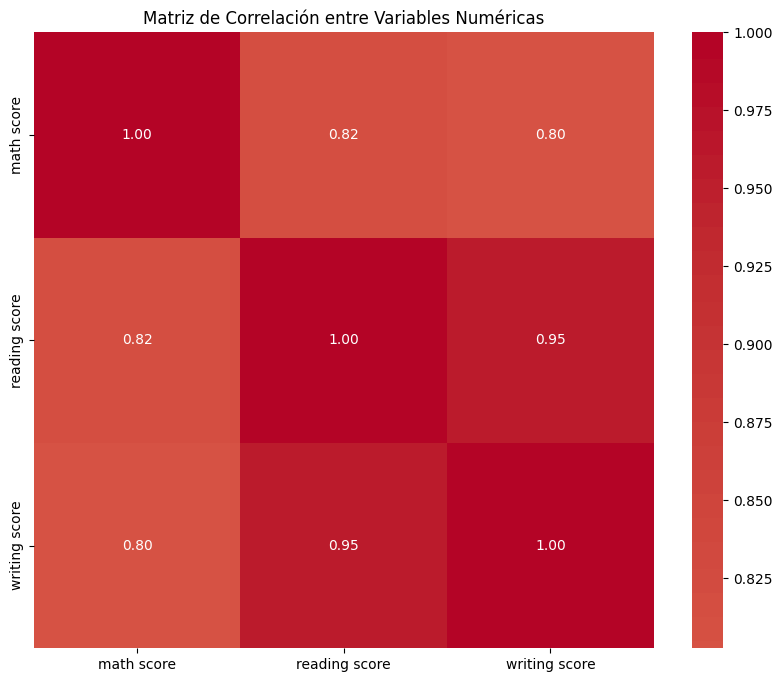

In [ ]:
# Correlación de los datos numéricos
correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix)

# Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

In [ ]:
# Sumas los valores numericos que son cero
print("Valore cero de math score",df[(df['math score'] == 0)].shape[0])
print("Valore cero de reading score",df[(df['reading score'] == 0)].shape[0])
print("Valore cero de writing score",df[(df['writing score'] == 0)].shape[0])

Valore cero de math score 1
Valore cero de reading score 0
Valore cero de writing score 0


In [ ]:
# Eliminar la fila cuyo valor math score es cero
df = df[df['math score'] != 0]

In [ ]:
# Función para identificar outliers usando IQR
def identify_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definición de límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificación de outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices.extend(outliers.index.tolist())

    return set(outlier_indices)

# Identificando outliers en las variables numéricas
outlier_indices = identify_outliers_iqr(df, numerical_cols)
num_outliers = len(outlier_indices)
num_data = len(df)

print(f"Número total de outliers identificados: {num_outliers}")
print(f"Porcentaje de outliers: {(num_outliers / num_data) * 100:.2f}%")

Número total de outliers identificados: 11
Porcentaje de outliers: 1.10%


In [ ]:
# Filtrar el DataFrame sin outliers
df_no_outliers = df.drop(index=outlier_indices)
print(f"Tamaño del DataFrame con outliers: {df.shape}")
print(f"Tamaño del DataFrame sin outliers: {df_no_outliers.shape}")

Tamaño del DataFrame con outliers: (999, 8)
Tamaño del DataFrame sin outliers: (988, 8)


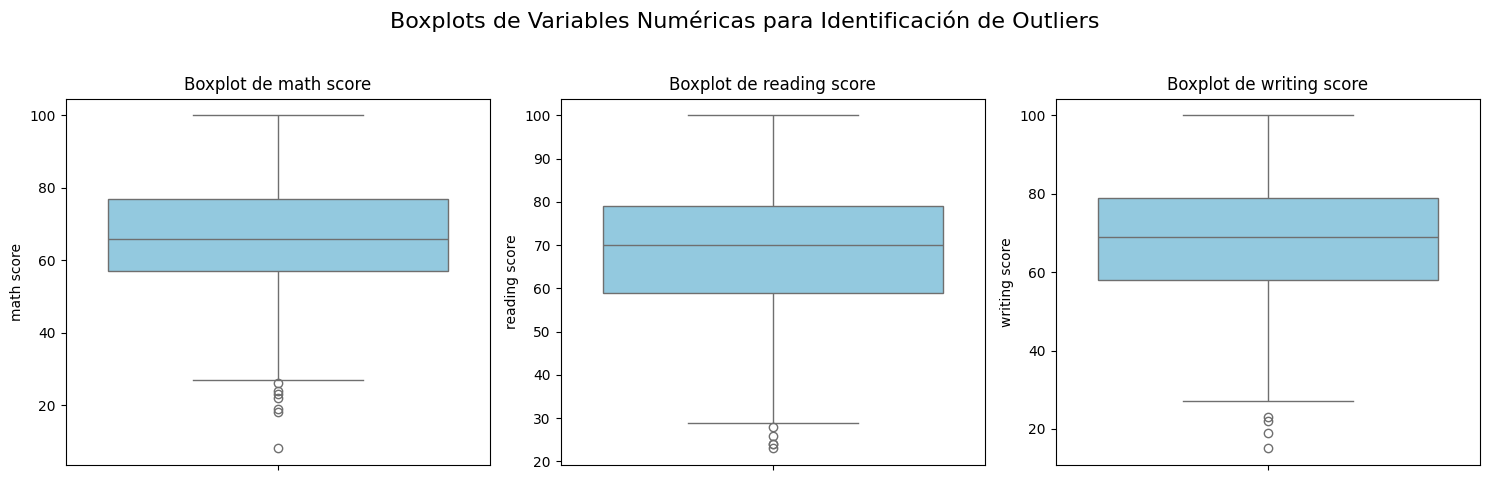

In [ ]:
# Definir el tamaño del gráfico y la cuadrícula de subplots
num_cols = 3  # Número de columnas de subplots
num_rows = (len(numerical_cols) + num_cols - 1) // num_cols  # Número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
fig.suptitle("Boxplots de Variables Numéricas para Identificación de Outliers", fontsize=16)

# Aplanar los ejes para iterar más fácilmente
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.boxplot(data=df, y=col, ax=ax, color='skyblue')
    ax.set_title(f"Boxplot de {col}")

# Eliminar subplots vacíos si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajusta el espaciado para el título principal
plt.show()

In [ ]:
# Filtrar el DataFrame sin outliers
df = df.drop(index=outlier_indices)

In [ ]:
# Información de los datos limpios
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 988 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       988 non-null    category
 1   race/ethnicity               988 non-null    category
 2   parental level of education  988 non-null    category
 3   lunch                        988 non-null    category
 4   test preparation course      988 non-null    category
 5   math score                   988 non-null    int64   
 6   reading score                988 non-null    int64   
 7   writing score                988 non-null    int64   
dtypes: category(5), int64(3)
memory usage: 36.5 KB


#Parte 1: Preprocesamiento de Datos

**Limpieza de Datos:**
* Tratar los valores nulos utilizando técnicas adecuadas (imputación, eliminación, etc.).
* Manejar los outliers mediante técnicas de filtrado o transformación.

**Transformación de Columnas:**
* Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.
* Realizar codificación de variables categóricas utilizando técnicas como One-Hot Encoding.
* Escalar las variables numéricas usando StandardScaler u otros métodos de normalización.

**Creación de Pipelines:**
* Crear pipelines utilizando Pipeline de sklearn para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.
* Incluir todos los pasos de preprocesamiento en el pipeline.

***- Valores nulos***

In [ ]:
# Verificar valores nulos
df.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


***- Valores outlier***

In [ ]:
# Función para identificar outliers usando IQR
def identify_outliers_iqr(df, columns):
    outlier_indices = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definición de límites
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identificación de outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices.extend(outliers.index.tolist())

    return set(outlier_indices)

# Identificando outliers en las variables numéricas
outlier_indices = identify_outliers_iqr(df, numerical_cols)
num_outliers = len(outlier_indices)
num_data = len(df)

print(f"Número total de outliers identificados: {num_outliers}")
print(f"Porcentaje de outliers: {(num_outliers / num_data) * 100:.2f}%")

Número total de outliers identificados: 2
Porcentaje de outliers: 0.20%


***- Visualizar columnas***

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
import pandas as pd

# Crear la columna average_score (promedio general)
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Crear la columna performance_category (categoría de rendimiento)
df['performance_category'] = pd.cut(
    df['average_score'],
    bins=[0, 70, 85, 100],  # Límites de las categorías
    labels=['Bajo', 'Medio', 'Alto']  # Etiquetas de las categorías
)

# Verificar el resultado
print(df[['average_score', 'performance_category']].head())


   average_score performance_category
0      72.666667                Medio
1      82.333333                Medio
2      92.666667                 Alto
3      49.333333                 Bajo
4      76.333333                Medio


performance_category
Bajo     541
Medio    335
Alto     112
Name: count, dtype: int64


<ipython-input-253-495ec78c1a9d>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='performance_category', data=df, palette='viridis')


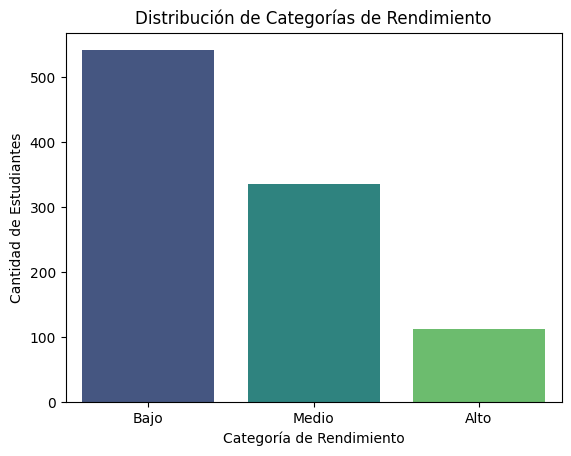

In [ ]:
# Verificar distribución de las categorías
print(df['performance_category'].value_counts())

# Visualizar la distribución con un gráfico
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='performance_category', data=df, palette='viridis')
plt.title('Distribución de Categorías de Rendimiento')
plt.xlabel('Categoría de Rendimiento')
plt.ylabel('Cantidad de Estudiantes')
plt.show()


In [ ]:
# Visualizar columnas numericas
df.select_dtypes(include=['float64', 'int64']).columns.tolist()

['math score', 'reading score', 'writing score', 'average_score']

In [ ]:
# Visualizar columnas categoricas
df.select_dtypes(include=['object', 'category']).columns.tolist()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'performance_category']

***- Transformación de Columnas y División del conjunto de datos en entrenamiento y prueba.***

In [ ]:
# Transformación de datos por Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Tipos de variable con la nueva distribución
numerical = ['math score', 'reading score', 'writing score']
categorical = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
target = 'performance_category'

# Crear transformaciones específicas para cada tipo de columna
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # OneHotEncoding
])
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Escalado de las características numéricas
])

# Crear el ColumnTransformer para aplicar las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical),  # Transformar las columnas categóricas
        ('num', numerical_transformer, numerical)  # Transformar las columnas numéricas
    ]
)

# Crear el pipeline final
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Excluir la columna 'performance_category' de las características a transformar
X = df.drop(columns=['performance_category', 'average_score'])
y = df['performance_category']

# Aplicar el preprocesamiento al DataFrame
df_transform = pipeline.fit_transform(X)

# Convertir el resultado a un DataFrame para una vista clara
df_transform = pd.DataFrame(df_transform, columns=pipeline.named_steps['preprocessor'].get_feature_names_out())

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_transform, y, test_size=0.3, random_state=42)

# Mostrar los primeros registros
df_transform.head()

,cat__gender_male,cat__race/ethnicity_group B,cat__race/ethnicity_group C,cat__race/ethnicity_group D,cat__race/ethnicity_group E,cat__parental level of education_bachelor's degree,cat__parental level of education_high school,cat__parental level of education_master's degree,cat__parental level of education_some college,cat__parental level of education_some high school,cat__lunch_standard,cat__test preparation course_none,num__math score,num__reading score,num__writing score
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.373174,0.168406,0.374241
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.164871,1.453233,1.338567
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.622992,1.810130,1.682969
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.362684,-0.902283,-1.692172
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.650912,0.596682,0.443121


***- División del conjunto de datos en entrenamiento y prueba.***

# Parte 2: Selección de Técnica de Machine Learning

**Entrenamiento Inicial:**
* Entrenar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost, LGBM).
* Evaluar los modelos utilizando validación cruzada y seleccionar el modelo con el mejor rendimiento inicial.

**Comparación de Modelos:**
* Comparar los modelos utilizando métricas de rendimiento relevantes (exactitud, precisión, recall, F1-Score, ROC-AUC, etc.).
* Seleccionar la técnica de machine learning más adecuada basándose en las métricas y la naturaleza del problema.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Definición de los modelos de clasificación
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Resultados almacenados
results = []

# Entrenar y evaluar cada modelo de clasificación
for model_name, model in models.items():
    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Métricas de evaluación
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)  # Guardar el reporte como diccionario

    # Almacenar resultados
    results.append({
        'Modelo': model_name,
        'Accuracy': accuracy,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    })

    # Imprimir resultados por modelo
    print(f"\n=== Modelo: {model_name} ===")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {report['weighted avg']['precision']:.2f}")
    print(f"Recall: {report['weighted avg']['recall']:.2f}")
    print(f"F1-Score: {report['weighted avg']['f1-score']:.2f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# Mostrar resumen final de resultados
import pandas as pd
results_df = pd.DataFrame(results)
print("\n=== Resumen de Resultados ===")
print(results_df)



=== Modelo: Logistic Regression ===
Accuracy: 0.96
Precision: 0.96
Recall: 0.96
F1-Score: 0.96
Confusion Matrix:
[[ 28   0   7]
 [  0 185   2]
 [  0   4  71]]

=== Modelo: K-Nearest Neighbors ===
Accuracy: 0.92
Precision: 0.93
Recall: 0.92
F1-Score: 0.92
Confusion Matrix:
[[ 23   0  12]
 [  0 179   8]
 [  0   5  70]]

=== Modelo: Decision Tree ===
Accuracy: 0.95
Precision: 0.95
Recall: 0.95
F1-Score: 0.95
Confusion Matrix:
[[ 27   0   8]
 [  0 185   2]
 [  0   5  70]]

=== Modelo: Random Forest ===
Accuracy: 0.94
Precision: 0.95
Recall: 0.94
F1-Score: 0.94
Confusion Matrix:
[[ 23   0  12]
 [  0 185   2]
 [  0   4  71]]

=== Resumen de Resultados ===
                Modelo  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.956229   0.958265  0.956229  0.955679
1  K-Nearest Neighbors  0.915825   0.926774  0.915825  0.915294
2        Decision Tree  0.949495   0.951865  0.949495  0.948666
3        Random Forest  0.939394   0.945082  0.939394  0.937162


# Parte 3: Optimización de Hiperparámetros

**GridSearchCV:**
* Implementar GridSearchCV para realizar una búsqueda exhaustiva de los mejores hiperparámetros para el modelo seleccionado.
* Definir el espacio de búsqueda para los hiperparámetros relevantes.

**RandomizedSearchCV:**
* Implementar RandomizedSearchCV para realizar una búsqueda aleatoria de los mejores hiperparámetros, especialmente útil si el espacio de búsqueda es grande.
Optuna:
* Implementar Optuna para una optimización avanzada de los hiperparámetros, aprovechando técnicas como la optimización bayesiana y el pruning.

**Evaluación de Modelos Optimizados:**
* Entrenar el modelo con los mejores hiperparámetros encontrados y evaluar su rendimiento en el conjunto de prueba.
* Comparar el rendimiento del modelo optimizado con el modelo inicial.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Definir el espacio de búsqueda de parámetros para cada modelo
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500]
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Crear el objeto GridSearchCV para cada modelo
grid_lr = GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_grid_lr, cv=5, scoring='accuracy')
grid_knn = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=param_grid_knn, cv=5, scoring='accuracy')
grid_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid_dt, cv=5, scoring='accuracy')
grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid_rf, cv=5, scoring='accuracy')

# Definir una lista de modelos para ejecutar
models = [grid_lr, grid_knn, grid_dt, grid_rf]

# Resultados almacenados
results = []

# Entrenar y evaluar cada modelo de clasificación con GridSearchCV
for model in models:
    model.fit(X_train, y_train)  # Entrenar el modelo con GridSearchCV

    # Mejor estimador y resultados
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Modelo': model.best_estimator_.__class__.__name__,
        'Accuracy': accuracy,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    })

    # Imprimir resultados por modelo
    print(f"\n=== Modelo: {model.best_estimator_.__class__.__name__} ===")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {report['weighted avg']['precision']:.2f}")
    print(f"Recall: {report['weighted avg']['recall']:.2f}")
    print(f"F1-Score: {report['weighted avg']['f1-score']:.2f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# Mostrar resumen final de resultados
import pandas as pd
results_df = pd.DataFrame(results)
print("\n=== Resumen de Resultados ===")
print(results_df)



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which 


=== Modelo: LogisticRegression ===
Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1-Score: 0.97
Confusion Matrix:
[[ 32   0   3]
 [  0 185   2]
 [  1   3  71]]

=== Modelo: KNeighborsClassifier ===
Accuracy: 0.89
Precision: 0.91
Recall: 0.89
F1-Score: 0.89
Confusion Matrix:
[[ 17   0  18]
 [  0 179   8]
 [  1   5  69]]

=== Modelo: DecisionTreeClassifier ===
Accuracy: 0.95
Precision: 0.95
Recall: 0.95
F1-Score: 0.95
Confusion Matrix:
[[ 27   0   8]
 [  0 185   2]
 [  0   5  70]]

=== Modelo: RandomForestClassifier ===
Accuracy: 0.93
Precision: 0.94
Recall: 0.93
F1-Score: 0.93
Confusion Matrix:
[[ 22   0  13]
 [  0 183   4]
 [  0   3  72]]

=== Resumen de Resultados ===
                   Modelo  Accuracy  Precision    Recall  F1-Score
0      LogisticRegression  0.969697   0.969768  0.969697  0.969622
1    KNeighborsClassifier  0.892256   0.907231  0.892256  0.888157
2  DecisionTreeClassifier  0.949495   0.951865  0.949495  0.948666
3  RandomForestClassifier  0.932660   0.941610  0.93266

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definir el espacio de búsqueda para RandomizedSearchCV de cada modelo
param_dist_lr = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': randint(100, 500)
}

param_dist_knn = {
    'n_neighbors': randint(3, 15),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

param_dist_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

param_dist_rf = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Crear el objeto RandomizedSearchCV para cada modelo
random_lr = RandomizedSearchCV(estimator=LogisticRegression(random_state=42), param_distributions=param_dist_lr, n_iter=100, cv=5, scoring='accuracy', random_state=42)
random_knn = RandomizedSearchCV(estimator=KNeighborsClassifier(), param_distributions=param_dist_knn, n_iter=100, cv=5, scoring='accuracy', random_state=42)
random_dt = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_distributions=param_dist_dt, n_iter=100, cv=5, scoring='accuracy', random_state=42)
random_rf = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), param_distributions=param_dist_rf, n_iter=100, cv=5, scoring='accuracy', random_state=42)

# Definir una lista de modelos para ejecutar
models = [random_lr, random_knn, random_dt, random_rf]

# Resultados almacenados
results = []

# Entrenar y evaluar cada modelo de clasificación con RandomizedSearchCV
for model in models:
    model.fit(X_train, y_train)  # Entrenar el modelo con RandomizedSearchCV

    # Mejor estimador y resultados
    best_model = model.best_estimator_
    y_pred = best_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Modelo': model.best_estimator_.__class__.__name__,
        'Accuracy': accuracy,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    })

    # Imprimir resultados por modelo
    print(f"\n=== Modelo: {model.best_estimator_.__class__.__name__} ===")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {report['weighted avg']['precision']:.2f}")
    print(f"Recall: {report['weighted avg']['recall']:.2f}")
    print(f"F1-Score: {report['weighted avg']['f1-score']:.2f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

# Mostrar resumen final de resultados
import pandas as pd
results_df = pd.DataFrame(results)
print("\n=== Resumen de Resultados ===")
print(results_df)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which 


=== Modelo: LogisticRegression ===
Accuracy: 0.97
Precision: 0.97
Recall: 0.97
F1-Score: 0.97
Confusion Matrix:
[[ 32   0   3]
 [  0 184   3]
 [  1   3  71]]

=== Modelo: KNeighborsClassifier ===
Accuracy: 0.91
Precision: 0.92
Recall: 0.91
F1-Score: 0.91
Confusion Matrix:
[[ 21   0  14]
 [  0 180   7]
 [  1   4  70]]

=== Modelo: DecisionTreeClassifier ===
Accuracy: 0.95
Precision: 0.95
Recall: 0.95
F1-Score: 0.95
Confusion Matrix:
[[ 27   0   8]
 [  0 185   2]
 [  0   5  70]]

=== Modelo: RandomForestClassifier ===
Accuracy: 0.93
Precision: 0.94
Recall: 0.93
F1-Score: 0.93
Confusion Matrix:
[[ 22   0  13]
 [  0 184   3]
 [  0   4  71]]

=== Resumen de Resultados ===
                   Modelo  Accuracy  Precision    Recall  F1-Score
0      LogisticRegression  0.966330   0.966651  0.966330  0.966353
1    KNeighborsClassifier  0.912458   0.922681  0.912458  0.910768
2  DecisionTreeClassifier  0.949495   0.951865  0.949495  0.948666
3  RandomForestClassifier  0.932660   0.940162  0.93266

#**Diagnóstico y Selección de Problema:**
* Basándose en el EDA inicial, diagnosticar las principales características y desafíos de cada conjunto de datos.
* Elegir una problemática específica para abordar (regresión, clasificación, clusterización, predicción).
* Justificar la elección del problema y explicar por qué es relevante y desafiante.

# Dataset I

**Diagnóstico:**
* Este conjunto de datos contiene información detallada sobre las ventas, incluyendo la categoría de producto, método de pago y el monto total de cada venta.
* Desafíos: Existen patrones complejos entre la categoría del producto y el método de pago que pueden afectar el volumen y monto de ventas. También puede haber estacionalidad en las ventas según la fecha.

**Problema Seleccionado:**
* Regresión para predecir el monto total de ventas.

**Justificación:**
* La predicción del monto total de ventas en función de factores como la categoría del producto y el método de pago es útil para gestionar el inventario y diseñar estrategias de marketing.
* Este problema es desafiante porque involucra analizar relaciones entre múltiples variables y potencialmente incluye factores estacionales que afectan las ventas.

# Dataset II

**Diagnóstico:**
* Incluye datos clínicos de pacientes, como edad, índice de masa corporal (IMC), presión arterial y otros indicadores de salud.
* Desafíos: El conjunto de datos puede tener valores atípicos en variables como el IMC y la presión arterial. También puede haber valores nulos en algunas variables.

**Problema Seleccionado:**
* Clasificación para predecir si un paciente tiene diabetes.

**Justificación:**
* La predicción de diabetes es de gran relevancia en la salud pública, ya que permite identificar a personas en riesgo y tomar medidas preventivas.
* Es un problema desafiante, ya que la diabetes depende de múltiples factores que interactúan de manera compleja, y además, el desequilibrio entre las clases (pacientes con y sin diabetes) puede complicar el modelo de clasificación.

# Dataset III

**Diagnóstico:**
* Este conjunto contiene información demográfica y médica de individuos (edad, género, IMC, historial de tabaquismo, entre otros) junto con el costo de sus seguros médicos.
* Desafíos: La variable objetivo (costo del seguro) tiene una alta variabilidad y puede estar influenciada por outliers, como gastos médicos extremos que pueden sesgar los resultados.

**Problema Seleccionado:**
* Regresión para predecir los gastos médicos personales.

**Justificación:**
* La predicción de costos médicos permite a las aseguradoras ajustar sus políticas de precios y detectar clientes de alto riesgo.
* Es un problema desafiante debido a la influencia de múltiples factores de salud y demográficos en el costo, así como la presencia de outliers significativos en los gastos médicos.

# Dataset IV

**Diagnóstico:**
* Objetivo: Explorar los factores que afectan el rendimiento académico y predecir el puntaje de los estudiantes en diferentes materias.
* Desafíos: Identificar la influencia de factores demográficos y socioeconómicos en el rendimiento de los estudiantes.

**Problema Seleccionado:**
* Clasificación para predecir el rendimiento académico.

**Justificación:**
* La predicción del rendimiento puede ayudar a diseñar intervenciones educativas, identificando factores que afectan el desempeño.
* Es un problema desafiante porque el rendimiento depende de múltiples factores externos e internos, y existe complejidad en determinar cuáles influyen más en los resultados académicos.